In [ ]:
# Imports
# !pip install pymatgen
# !pip install smact
# !pip install entmax
# !pip install umap-learn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 38.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 93.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 332.3/332.3 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 14.0 MB/s eta 0:00:00
  Created wheel for bibtexparser: filename=bibtexparser-1.4.4-py3-none-any.whl size=43609 sha256=c20b46a7bcbcfb40d39747c398959ef4d991c1c4bd37e28d68abd488aac11a88
  Sto

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Mounted at /content/drive


In [37]:
# ============================================================
# IMPORTS
# ============================================================

import os
import math
import warnings
import random

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

from torch.nn.utils import spectral_norm

from pymatgen.core import Composition

from smact.screening import smact_validity

from entmax import entmax15

warnings.filterwarnings("ignore")

In [38]:
# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print(f"\nUSING DEVICE: {device}")


USING DEVICE: cuda


In [39]:
# # ============================================================
# # CONFIG
# # ============================================================

# FORMULA_CSV = "/content/final_cleaned_materials_dataset.csv"

# EMBEDDING_CSV = "/content/mat2vec.csv"

# FORMULA_COLUMN = "Normalized_Formula"



# MAX_ELEMENTS = 8

# D_MODEL = 256

# LATENT_DIM = 128

# CONDITION_DIM = 6

# COND_EMB_DIM= 32

# NUM_HEADS = 4

# NUM_ENCODER_LAYERS = 6

# NUM_DECODER_LAYERS = 12

# BATCH_SIZE = 1024

# EPOCHS = 1500

# LR_G = 1e-4

# LR_D = 1e-4

# BETA1 = 0.0
# BETA2 = 0.9

# N_CRITIC = 5

# LAMBDA_GP = 10

# MAX_KL_WEIGHT = 1e-4

# GAN_WEIGHT = 0.1

# DIVERSITY_WEIGHT = 0.05

# CONDITION_WEIGHT = 0.5

# SPARSITY_WEIGHT = 0.01

# SAVE_INTERVAL = 50

# RESUME_TRAINING = True

# CHECKPOINT_PATH = (
#     f"/content/drive/MyDrive/India_AI_Final-Set_CVAE/experimental_depth{NUM_DECODER_LAYERS}_encoder_{NUM_ENCODER_LAYERS}_explainable_wgan_gp_materials.pt"
# )

In [40]:
# ============================================================
# CONFIG
# ============================================================

FORMULA_CSV = "/content/final_cleaned_materials_dataset.csv"

EMBEDDING_CSV = "/content/mat2vec.csv"

FORMULA_COLUMN = "Normalized_Formula"


# ============================================================
# MODEL CONFIG
# ============================================================

MAX_ELEMENTS = 8

D_MODEL = 256

LATENT_DIM = 128

CONDITION_DIM = 6

COND_EMB_DIM = 32

NUM_HEADS = 4

NUM_ENCODER_LAYERS = 6

NUM_DECODER_LAYERS = 12


# ============================================================
# TRAINING CONFIG
# ============================================================

BATCH_SIZE = 1024

EPOCHS = 1200

LR_G = 1e-4

LR_D = 1e-4

BETA1 = 0.0

BETA2 = 0.9

N_CRITIC = 3

LAMBDA_GP = 10


# ============================================================
# LOSS WEIGHTS
# ============================================================

MAX_KL_WEIGHT = 5e-4

GAN_WEIGHT = 0.05

DIVERSITY_WEIGHT = 0.12

CONDITION_WEIGHT = 1.0

SPARSITY_WEIGHT = 0.02


# ============================================================
# CHECKPOINT
# ============================================================

SAVE_INTERVAL = 50

RESUME_TRAINING = True

CHECKPOINT_PATH = (
    f"/content/drive/MyDrive/India_AI_Final-Set_CVAE/"
    f"new_experimental_depth{NUM_DECODER_LAYERS}_"
    f"encoder_{NUM_ENCODER_LAYERS}_"
    f"explainable_wgan_gp_materials.pt"
)


# ============================================================
# SAMPLING CONFIG
# ============================================================

SAMPLING_TEMPERATURE = 1.15

In [41]:
# ============================================================
# DATASET & apply Coinditions
# ============================================================

df = pd.read_csv(FORMULA_CSV)

print(f"\nDATASET SIZE: {len(df)}")

# ============================================================
# CONDITIONS
# ============================================================

def assign_condition(zt, temp):

    if temp < 300:
        temp_cls = "LT"

    elif temp <= 600:
        temp_cls = "MT"

    else:
        temp_cls = "HT"

    if zt >= 1:
        zt_cls = "HzT"

    else:
        zt_cls = "LzT"

    return f"{zt_cls}_{temp_cls}"

df["condition"] = df.apply(

    lambda row: assign_condition(

        row["ZT_value"],

        row["ZT_temperature"]

    ),

    axis=1
)

all_conditions = [

    "LzT_LT",
    "HzT_LT",

    "LzT_MT",
    "HzT_MT",

    "LzT_HT",
    "HzT_HT"
]

condition_dummies = pd.get_dummies(
    df["condition"]
)

condition_dummies = condition_dummies.reindex(

    columns=all_conditions,

    fill_value=0
)

df = pd.concat(

    [df, condition_dummies],

    axis=1
)



DATASET SIZE: 7277


In [42]:
# ============================================================
# LOAD Embeding Vectors
# ============================================================

embedding_df = pd.read_csv(
    EMBEDDING_CSV
)

symbol_col = embedding_df.columns[0]

elements = (

    embedding_df[symbol_col]

    .astype(str)

    .str.strip()

    .values
)

embeddings = (

    embedding_df

    .drop(columns=[symbol_col])

    .select_dtypes(include=[np.number])

    .fillna(0)

    .values

    .astype(np.float32)
)

INVALID_ELEMENTS = {

    "He","Ne","Ar","Kr","Xe","Rn","Og",

    "Rf","Db","Sg","Bh","Hs",
    "Mt","Ds","Rg","Cn",

    "Nh","Fl","Mc","Lv","Ts"
}

valid_idx = []

for i, el in enumerate(elements):

    if el not in INVALID_ELEMENTS:

        valid_idx.append(i)

elements = elements[valid_idx]

embeddings = embeddings[valid_idx]

n_elements, embedding_dim = embeddings.shape

print(f"\nVALID ELEMENTS: {n_elements}")



VALID ELEMENTS: 97


In [43]:
# ============================================================
# ELEMENT MAPS
# ============================================================

element_to_idx = {

    el: i + 1

    for i, el in enumerate(elements)
}

idx_to_element = {

    i + 1: el

    for i, el in enumerate(elements)
}

# ============================================================
# EMBEDDING LAYER
# ============================================================

embedding_layer = nn.Embedding(

    n_elements + 1,

    embedding_dim,

    padding_idx=0
)

embedding_layer.weight.data[1:] = (
    torch.tensor(embeddings)
)

embedding_layer = embedding_layer.to(device)

# ============================================================
# FRACTIONAL ENCODER
# ============================================================

class FractionalEncoder(nn.Module):

    def __init__(

        self,

        d_model,

        resolution=5000,

        log_scale=False
    ):

        super().__init__()

        self.resolution = resolution

        self.log_scale = log_scale

        pe = torch.zeros(
            resolution,
            d_model
        )

        position = torch.arange(
            resolution
        ).unsqueeze(1)

        div_term = torch.exp(

            torch.arange(
                0,
                d_model,
                2
            ) * (
                -math.log(10000.0)
                / d_model
            )
        )

        pe[:,0::2] = torch.sin(
            position * div_term
        )

        pe[:,1::2] = torch.cos(
            position * div_term
        )

        self.register_buffer(
            "pe",
            pe
        )

    def forward(self, fractions):

        x = fractions.clone()

        if self.log_scale:

            x = 0.0025 * (

                torch.log2(

                    torch.clamp(
                        x,
                        min=1e-6
                    )

                )

            )**2

            x = torch.clamp(x, max=1)

        x = torch.clamp(

            x,

            min=1/self.resolution
        )

        idx = (
            x * self.resolution
        ).long() - 1

        idx = torch.clamp(

            idx,

            0,

            self.resolution - 1
        )

        return self.pe[idx].to(
            fractions.device
        )

frac_encoder = FractionalEncoder(
    D_MODEL,
    log_scale=False
).to(device)

log_frac_encoder = FractionalEncoder(
    D_MODEL,
    log_scale=True
).to(device)


In [44]:
# ===================================================================================================
# TOKENIZER -> Split the chemical formulas into Elements, Fractions & Occupancy
# ===================================================================================================

def formula_to_tokens(formula):

    try:

        comp = Composition(formula)

    except:

        return None, None, None

    frac_comp = comp.fractional_composition

    pairs = []

    for el, val in frac_comp.items():

        symbol = el.symbol

        if symbol not in element_to_idx:
            continue

        pairs.append((
            symbol,
            float(val)
        ))

    pairs = sorted(

        pairs,

        key=lambda x: x[1],

        reverse=True
    )

    element_ids = []

    fractions = []

    occupancy = []

    for symbol, val in pairs:

        element_ids.append(
            element_to_idx[symbol]
        )

        fractions.append(val)

        occupancy.append(1)

    while len(element_ids) < MAX_ELEMENTS:

        element_ids.append(0)

        fractions.append(0.0)

        occupancy.append(0)

    return (

        element_ids[:MAX_ELEMENTS],

        fractions[:MAX_ELEMENTS],

        occupancy[:MAX_ELEMENTS]
    )

In [45]:
# ============================================================
# DATASET -> Custom Dataset & data loaders
# ============================================================

class MaterialDataset(Dataset):

    def __init__(self, df):

        self.df = df

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        formula = row[
            FORMULA_COLUMN
        ]

        element_ids, fractions, occupancy = (
            formula_to_tokens(formula)
        )

        condition = (

            row[all_conditions]

            .values

            .astype(np.float32)
        )

        return (

            torch.tensor(element_ids).long(),

            torch.tensor(fractions).float(),

            torch.tensor(occupancy).float(),

            torch.tensor(condition).float()
        )

train_dataset = MaterialDataset(df)

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    drop_last=True
)


In [46]:
# ============================================================
# EDM BUILDER
# ============================================================

class EDMBuilder(nn.Module):

    def __init__(self):

        super().__init__()

        self.embedding_projection = nn.Linear(

            embedding_dim,

            D_MODEL
        )

    def forward(

        self,

        element_ids,

        fractions
    ):

        element_embedding = embedding_layer(
            element_ids
        )

        element_embedding = (
            self.embedding_projection(
                element_embedding
            )
        )

        frac_encoding = frac_encoder(
            fractions
        )

        log_frac_encoding = (
            log_frac_encoder(fractions)
        )

        edm = (

            element_embedding

            + frac_encoding

            + log_frac_encoding
        )

        return edm

edm_builder = EDMBuilder().to(device)

In [47]:
# ============================================================
# ATTENTION BLOCKS
# ============================================================


class ExplainableMAB(nn.Module):

    def __init__(self, dim, heads=4):

        super().__init__()

        self.attn = nn.MultiheadAttention(
            embed_dim=dim,
            num_heads=heads,
            batch_first=True
        )

        self.ln1 = nn.LayerNorm(dim)

        self.ff = nn.Sequential(
            nn.Linear(dim, dim * 4),
            nn.GELU(),
            nn.Linear(dim * 4, dim)
        )

        self.ln2 = nn.LayerNorm(dim)

        # =====================================
        # NEW
        # =====================================

        self.store_attention = False
        self.last_attention = None

    def forward(self, x, context=None):

        if context is None:
            context = x

        out, attn = self.attn(
            x,
            context,
            context,
            need_weights=True,
            average_attn_weights=False
        )

        # =====================================
        # STORE ATTENTION
        # =====================================

        if self.store_attention:
            self.last_attention = attn.detach()

        x = self.ln1(x + out)

        ff = self.ff(x)

        x = self.ln2(x + ff)

        return x

class ExplainableSAB(nn.Module):

    def __init__(self, dim, heads=4):

        super().__init__()

        self.mab = ExplainableMAB(
            dim,
            heads
        )

    def forward(self, x):

        return self.mab(x)

class ExplainableCrossAttention(nn.Module):

    def __init__(self, dim, heads=4):

        super().__init__()

        self.cross = ExplainableMAB(
            dim,
            heads
        )

        self.self_attn = ExplainableSAB(
            dim,
            heads
        )

    def forward(self, q, memory):

        q = self.cross(q, memory)

        q = self.self_attn(q)

        return q

In [48]:
# ============================================================
# CONDITION EMBEDDING
# ============================================================

class ConditionEmbedding(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(

            nn.Linear(
                CONDITION_DIM,
                64
            ),

            nn.GELU(),

            nn.Linear(
                64,
                COND_EMB_DIM
            )
        )

    def forward(self, c):

        return self.net(c)

In [49]:
# ============================================================
# CONDITION-AWARE ENCODER
# q(z | x, c)
# ============================================================

class SetTransformerEncoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.layers = nn.ModuleList([

            ExplainableSAB(
                D_MODEL,
                NUM_HEADS
            )

            for _ in range(NUM_ENCODER_LAYERS)
        ])

        # ----------------------------------------------------
        # CONDITION PROJECTION
        # ----------------------------------------------------

        self.condition_proj = nn.Sequential(

            nn.Linear(
                COND_EMB_DIM,
                D_MODEL
            ),

            nn.LayerNorm(D_MODEL),

            nn.GELU()
        )

        # ----------------------------------------------------
        # CONDITION CROSS ATTENTION
        # ----------------------------------------------------

        self.condition_cross = ExplainableMAB(

            D_MODEL,

            NUM_HEADS
        )

        # ----------------------------------------------------
        # POOLING
        # ----------------------------------------------------

        self.pool_query = nn.Parameter(

            torch.randn(
                1,
                1,
                D_MODEL
            )
        )

        self.pool_attn = ExplainableMAB(

            D_MODEL,

            NUM_HEADS
        )

        # ----------------------------------------------------
        # LATENT HEADS
        # ----------------------------------------------------

        self.fc_mu = nn.Sequential(

            nn.Linear(
                D_MODEL,
                D_MODEL
            ),

            nn.GELU(),

            nn.Linear(
                D_MODEL,
                LATENT_DIM
            )
        )

        self.fc_logvar = nn.Sequential(

            nn.Linear(
                D_MODEL,
                D_MODEL
            ),

            nn.GELU(),

            nn.Linear(
                D_MODEL,
                LATENT_DIM
            )
        )

    def forward(

        self,
        edm,
        cond_emb
    ):

        x = edm

        # ----------------------------------------------------
        # SELF ATTENTION
        # ----------------------------------------------------

        for layer in self.layers:

            x = layer(x)

        # ----------------------------------------------------
        # CONDITION TOKEN
        # ----------------------------------------------------

        cond_token = self.condition_proj(
            cond_emb
        ).unsqueeze(1)

        # ----------------------------------------------------
        # CONDITION CROSS ATTENTION
        # ----------------------------------------------------

        cond_context = self.condition_cross(

            cond_token,

            x
        )

        # ----------------------------------------------------
        # CONCAT CONDITION + MATERIAL TOKENS
        # ----------------------------------------------------

        x = torch.cat(

            [cond_context, x],

            dim=1
        )

        # ----------------------------------------------------
        # POOLING
        # ----------------------------------------------------

        B = x.size(0)

        q = self.pool_query.repeat(

            B,
            1,
            1
        )

        pooled = self.pool_attn(
            q,
            x
        )

        pooled = pooled.squeeze(1)

        # ----------------------------------------------------
        # LATENT DISTRIBUTION
        # ----------------------------------------------------

        mu = self.fc_mu(
            pooled
        )

        logvar = self.fc_logvar(
            pooled
        )

        return mu, logvar

In [50]:
# ============================================================
# DECODER
# ============================================================

class SetTransformerDecoder(nn.Module):

    def __init__(self):

        super().__init__()

        self.memory_proj = nn.Sequential(

            nn.Linear(

                LATENT_DIM + COND_EMB_DIM,

                D_MODEL * 4
            ),

            nn.GELU(),

            nn.Linear(

                D_MODEL * 4,

                D_MODEL * MAX_ELEMENTS
            )
        )

        self.query_embed = nn.Parameter(

            torch.randn(

                1,

                MAX_ELEMENTS,

                D_MODEL
            )
        )

        self.layers = nn.ModuleList([

            ExplainableCrossAttention(

                D_MODEL,

                NUM_HEADS

            )

            for _ in range(NUM_DECODER_LAYERS)
        ])

        self.element_head = nn.Linear(

            D_MODEL,

            n_elements + 1
        )

        self.fraction_head = nn.Sequential(

            nn.Linear(
                D_MODEL,
                128
            ),

            nn.GELU(),

            nn.Linear(
                128,
                1
            )
        )

        self.occupancy_head = nn.Linear(

            D_MODEL,

            1
        )

    def forward(self, z, cond_emb):

        # ----------------------------------------------------
        # CONCAT LATENT + CONDITION
        # ----------------------------------------------------

        latent = torch.cat(

            [z, cond_emb],

            dim=-1
        )

        # ----------------------------------------------------
        # MEMORY
        # ----------------------------------------------------

        memory = self.memory_proj(
            latent
        )

        memory = memory.view(

            latent.size(0),

            MAX_ELEMENTS,

            D_MODEL
        )

        # ----------------------------------------------------
        # QUERIES
        # ----------------------------------------------------

        B = z.size(0)

        q = self.query_embed.repeat(
            B,
            1,
            1
        )

        # ----------------------------------------------------
        # CROSS ATTENTION
        # ----------------------------------------------------

        for layer in self.layers:

            q = layer(q, memory)

        # ----------------------------------------------------
        # OUTPUT HEADS
        # ----------------------------------------------------

        element_logits = self.element_head(q)

        fractions = self.fraction_head(q)

        fractions = fractions.squeeze(-1)

        fractions = entmax15(

            fractions,

            dim=-1
        )

        occupancy = torch.sigmoid(

            self.occupancy_head(q)

        ).squeeze(-1)

        return (

            element_logits,

            fractions,

            occupancy
        )

In [51]:
# ============================================================
# WGAN CRITIC
# ============================================================

class Critic(nn.Module):

    def __init__(self):

        super().__init__()

        self.layers = nn.ModuleList([

            ExplainableSAB(
                D_MODEL,
                NUM_HEADS
            )

            for _ in range(3)
        ])

        self.classifier = nn.Sequential(

            spectral_norm(
                nn.Linear(D_MODEL, 256)
            ),

            nn.GELU(),

            spectral_norm(
                nn.Linear(256, 1)
            )
        )

    def forward(self, edm):

        x = edm

        for layer in self.layers:

            x = layer(x)

        pooled = x.mean(dim=1)

        return self.classifier(pooled)

In [52]:
# ============================================================
# CONDITION DISCRIMINATOR
# ============================================================

class ConditionDiscriminator(nn.Module):

    def __init__(self):

        super().__init__()

        # ----------------------------------------------------
        # MATERIAL FEATURE EXTRACTION
        # ----------------------------------------------------

        self.layers = nn.ModuleList([

            ExplainableSAB(
                D_MODEL,
                NUM_HEADS
            )

            for _ in range(3)
        ])

        # ----------------------------------------------------
        # CONDITION PROJECTION
        # ----------------------------------------------------

        self.condition_proj = nn.Sequential(

            nn.Linear(
                COND_EMB_DIM,
                D_MODEL
            ),

            nn.LayerNorm(D_MODEL),

            nn.GELU()
        )

        # ----------------------------------------------------
        # CONDITION CROSS ATTENTION
        # ----------------------------------------------------

        self.condition_cross = ExplainableMAB(

            D_MODEL,

            NUM_HEADS
        )

        # ----------------------------------------------------
        # CLASSIFIER
        # ----------------------------------------------------

        self.classifier = nn.Sequential(

            spectral_norm(
                nn.Linear(
                    D_MODEL,
                    256
                )
            ),

            nn.GELU(),

            nn.Dropout(0.2),

            spectral_norm(
                nn.Linear(
                    256,
                    128
                )
            ),

            nn.GELU(),

            spectral_norm(
                nn.Linear(
                    128,
                    CONDITION_DIM
                )
            )
        )

    def forward(

        self,
        edm,
        cond_emb
    ):

        x = edm

        # ----------------------------------------------------
        # MATERIAL ATTENTION
        # ----------------------------------------------------

        for layer in self.layers:

            x = layer(x)

        # ----------------------------------------------------
        # CONDITION TOKEN
        # ----------------------------------------------------

        cond_token = self.condition_proj(
            cond_emb
        ).unsqueeze(1)

        # ----------------------------------------------------
        # CONDITION-MATERIAL INTERACTION
        # ----------------------------------------------------

        cond_context = self.condition_cross(

            cond_token,

            x
        )

        cond_context = cond_context.squeeze(1)

        # ----------------------------------------------------
        # CLASSIFICATION
        # ----------------------------------------------------

        logits = self.classifier(
            cond_context
        )

        return logits


In [53]:
# ============================================================
# BUILD MODELS
# ============================================================

encoder = SetTransformerEncoder().to(device)

decoder = SetTransformerDecoder().to(device)

condition_embedding = (
    ConditionEmbedding().to(device)
)

D_real_fake = Critic().to(device)

D_condition = (
    ConditionDiscriminator().to(device)
)


# ============================================================
# OPTIMIZERS
# ============================================================

optimizer_G = optim.Adam(

    list(encoder.parameters())

    + list(decoder.parameters())

    + list(condition_embedding.parameters()),

    lr=LR_G,

    betas=(BETA1, BETA2)
)

optimizer_D_rf = optim.Adam(

    D_real_fake.parameters(),

    lr=LR_D,

    betas=(BETA1, BETA2)
)

optimizer_D_cond = optim.Adam(

    D_condition.parameters(),

    lr=LR_D,

    betas=(BETA1, BETA2)
)


In [54]:
# ============================================================
# RESUME TRAINING
# ============================================================

start_epoch = 0

if RESUME_TRAINING and os.path.exists(CHECKPOINT_PATH):

    checkpoint = torch.load(

        CHECKPOINT_PATH,

        map_location=device
    )

    encoder.load_state_dict(
        checkpoint["encoder"]
    )

    decoder.load_state_dict(
        checkpoint["decoder"]
    )

    condition_embedding.load_state_dict(
        checkpoint["condition_embedding"]
    )

    D_real_fake.load_state_dict(
        checkpoint["critic_real_fake"]
    )

    D_condition.load_state_dict(
        checkpoint["condition_discriminator"]
    )

    optimizer_G.load_state_dict(
        checkpoint["optimizer_G"]
    )

    optimizer_D_rf.load_state_dict(
        checkpoint["optimizer_D_rf"]
    )

    optimizer_D_cond.load_state_dict(
        checkpoint["optimizer_D_cond"]
    )

    start_epoch = checkpoint["epoch"]

    print(
        f"\nRESUMED FROM EPOCH {start_epoch}"
    )


# ============================================================
# LOSSES
# ============================================================

ce_loss = nn.CrossEntropyLoss(
    ignore_index=0
)

condition_ce = nn.CrossEntropyLoss()

mse_loss = nn.MSELoss()

scaler = torch.cuda.amp.GradScaler()


# ============================================================
# KL DIVERGENCE
# ============================================================

def kl_divergence(mu, logvar):

    return -0.5 * torch.mean(

        1

        + logvar

        - mu.pow(2)

        - logvar.exp()
    )


# ============================================================
# REPARAMETERIZATION
# ============================================================

def reparameterize(mu, logvar):

    std = torch.exp(
        0.5 * logvar
    )

    eps = torch.randn_like(std)

    return mu + eps * std


# ============================================================
# GRADIENT PENALTY
# ============================================================

def compute_gradient_penalty(

    critic,

    real_samples,

    fake_samples
):

    alpha = torch.rand(

        real_samples.size(0),

        1,

        1,

        device=device
    )

    interpolates = (

        alpha * real_samples

        + (1 - alpha) * fake_samples

    ).requires_grad_(True)

    critic_interpolates = critic(
        interpolates
    )

    gradients = torch.autograd.grad(

        outputs=critic_interpolates,

        inputs=interpolates,

        grad_outputs=torch.ones_like(
            critic_interpolates
        ),

        create_graph=True,

        retain_graph=True,

        only_inputs=True

    )[0]

    gradients = gradients.view(
        gradients.size(0),
        -1
    )

    gp = (

        (
            gradients.norm(2, dim=1)
            - 1
        ) ** 2

    ).mean()

    return gp


# ============================================================
# DIVERSITY LOSS
# ============================================================

def diversity_loss(pred_fractions):

    entropy = -(

        pred_fractions

        * torch.log(
            pred_fractions + 1e-8
        )

    ).sum(dim=-1)

    return -entropy.mean()


# ============================================================
# DIFFERENTIABLE EDM BUILDER
# ============================================================

def build_soft_edm(

    fake_probs,
    pred_fractions
):

    element_embedding_matrix = (
        embedding_layer.weight
    )

    soft_embeddings = torch.matmul(

        fake_probs,

        element_embedding_matrix
    )

    soft_embeddings = (
        edm_builder.embedding_projection(
            soft_embeddings
        )
    )

    frac_encoding = frac_encoder(
        pred_fractions
    )

    log_frac_encoding = (
        log_frac_encoder(
            pred_fractions
        )
    )

    fake_edm = (

        soft_embeddings

        + frac_encoding

        + log_frac_encoding
    )

    return fake_edm


# ============================================================
# IDS TO FORMULA
# ============================================================

def ids_to_formula(ids, fracs, occupancy):

    parts = []

    used = set()

    for idx, frac, occ in zip(

        ids,

        fracs,

        occupancy
    ):

        idx = idx.item()

        frac = frac.item()

        occ = occ.item()

        if occ < 0.5:
            continue

        if frac < 0.01:
            continue

        if idx == 0:
            continue

        if idx in used:
            continue

        used.add(idx)

        symbol = idx_to_element[idx]

        parts.append(
            f"{symbol}{frac:.3f}"
        )

    return "".join(parts)



In [55]:
# # ============================================================
# # TRAINING
# # ============================================================

# print("\nSTARTING TRAINING")

# for epoch in range(start_epoch, EPOCHS):

#     encoder.train()

#     decoder.train()

#     D_real_fake.train()

#     D_condition.train()

#     condition_embedding.train()

#     KL_WEIGHT = min(

#         MAX_KL_WEIGHT,

#         (epoch / 100)
#         * MAX_KL_WEIGHT
#     )

#     for batch in train_loader:

#         (
#             element_ids,
#             fractions,
#             occupancy_gt,
#             condition

#         ) = batch

#         element_ids = element_ids.to(device)

#         fractions = fractions.to(device)

#         occupancy_gt = occupancy_gt.to(device)

#         condition = condition.to(device)

#         # ====================================================
#         # CONDITION LABELS
#         # ====================================================

#         condition_labels = torch.argmax(

#             condition,

#             dim=1
#         )

#         # ====================================================
#         # REAL EDM
#         # ====================================================

#         real_edm = edm_builder(

#             element_ids,

#             fractions
#         )

#         # ====================================================
#         # CONDITION EMBEDDING
#         # ====================================================

#         cond_emb = condition_embedding(
#             condition
#         )

#         # ====================================================
#         # ENCODER
#         # ====================================================

#         with torch.cuda.amp.autocast():

#             mu, logvar = encoder(

#                 real_edm,

#                 cond_emb
#             )

#             z = reparameterize(
#                 mu,
#                 logvar
#             )

#             (
#                 pred_elements,
#                 pred_fractions,
#                 pred_occupancy

#             ) = decoder(
#                 z,
#                 cond_emb
#             )

#             # =================================================
#             # GUMBEL SOFTMAX
#             # =================================================

#             fake_probs = F.gumbel_softmax(

#                 pred_elements,

#                 tau=0.7,

#                 hard=False,

#                 dim=-1
#             )

#             # =================================================
#             # DIFFERENTIABLE EDM
#             # =================================================

#             fake_edm = build_soft_edm(

#                 fake_probs,

#                 pred_fractions
#             )

#         # ====================================================
#         # TRAIN WGAN CRITIC
#         # ====================================================

#         for _ in range(N_CRITIC):

#             optimizer_D_rf.zero_grad()

#             with torch.cuda.amp.autocast():

#                 real_score = D_real_fake(
#                     real_edm.detach()
#                 )

#                 fake_score = D_real_fake(
#                     fake_edm.detach()
#                 )

#                 gp = compute_gradient_penalty(

#                     D_real_fake,

#                     real_edm.detach(),

#                     fake_edm.detach()
#                 )

#                 d_loss = (

#                     fake_score.mean()

#                     - real_score.mean()

#                     + LAMBDA_GP * gp
#                 )

#             scaler.scale(d_loss).backward()

#             scaler.step(optimizer_D_rf)

#             scaler.update()

#         # ====================================================
#         # TRAIN CONDITION DISCRIMINATOR
#         # ====================================================

#         optimizer_D_cond.zero_grad()

#         with torch.cuda.amp.autocast():

#             # ------------------------------------------------
#             # REAL
#             # ------------------------------------------------

#             real_condition_logits = D_condition(

#                 real_edm.detach(),

#                 cond_emb.detach()
#             )

#             real_condition_loss = condition_ce(

#                 real_condition_logits,

#                 condition_labels
#             )

#             # ------------------------------------------------
#             # FAKE
#             # ------------------------------------------------

#             fake_condition_logits = D_condition(

#                 fake_edm.detach(),

#                 cond_emb.detach()
#             )

#             fake_condition_loss = condition_ce(

#                 fake_condition_logits,

#                 condition_labels
#             )

#             cond_d_loss = (

#                 real_condition_loss

#                 + fake_condition_loss

#             ) * 0.5

#         scaler.scale(cond_d_loss).backward()

#         scaler.step(optimizer_D_cond)

#         scaler.update()

#         # ====================================================
#         # TRAIN GENERATOR
#         # ====================================================

#         optimizer_G.zero_grad()

#         with torch.cuda.amp.autocast():

#             # ------------------------------------------------
#             # ADVERSARIAL LOSS
#             # ------------------------------------------------

#             fake_score = D_real_fake(
#                 fake_edm
#             )

#             gan_loss = -fake_score.mean()

#             # ------------------------------------------------
#             # CONDITION MATCH LOSS
#             # ------------------------------------------------

#             fake_condition_logits = D_condition(

#                 fake_edm,

#                 cond_emb
#             )

#             condition_match_loss = condition_ce(

#                 fake_condition_logits,

#                 condition_labels
#             )

#             # ------------------------------------------------
#             # ELEMENT LOSS
#             # ------------------------------------------------

#             element_loss = ce_loss(

#                 pred_elements.view(
#                     -1,
#                     n_elements + 1
#                 ),

#                 element_ids.view(-1)
#             )

#             # ------------------------------------------------
#             # FRACTION LOSS
#             # ------------------------------------------------

#             fraction_loss = F.kl_div(

#                 torch.log(
#                     pred_fractions + 1e-8
#                 ),

#                 fractions,

#                 reduction="batchmean"
#             )

#             # ------------------------------------------------
#             # OCCUPANCY LOSS
#             # ------------------------------------------------

#             occupancy_loss = mse_loss(

#                 pred_occupancy,

#                 occupancy_gt
#             )

#             # ------------------------------------------------
#             # SPARSITY LOSS
#             # ------------------------------------------------

#             sparsity_loss = (
#                 pred_occupancy.mean()
#             )

#             # ------------------------------------------------
#             # RECONSTRUCTION
#             # ------------------------------------------------

#             recon_loss = (

#                 element_loss

#                 + fraction_loss

#                 + occupancy_loss
#             )

#             # ------------------------------------------------
#             # KL LOSS
#             # ------------------------------------------------

#             kl_loss = kl_divergence(
#                 mu,
#                 logvar
#             )

#             # ------------------------------------------------
#             # DIVERSITY LOSS
#             # ------------------------------------------------

#             div_loss = diversity_loss(
#                 pred_fractions
#             )

#             # ------------------------------------------------
#             # FINAL GENERATOR LOSS
#             # ------------------------------------------------

#             g_loss = (

#                 recon_loss

#                 + KL_WEIGHT * kl_loss

#                 + GAN_WEIGHT * gan_loss

#                 + DIVERSITY_WEIGHT * div_loss

#                 + CONDITION_WEIGHT
#                 * condition_match_loss

#                 + SPARSITY_WEIGHT
#                 * sparsity_loss
#             )

#         scaler.scale(g_loss).backward()

#         torch.nn.utils.clip_grad_norm_(

#             list(encoder.parameters())

#             + list(decoder.parameters())

#             + list(condition_embedding.parameters()),

#             max_norm=5.0
#         )

#         scaler.step(optimizer_G)

#         scaler.update()

#     # ========================================================
#     # LOGGING
#     # ========================================================

#     if (epoch + 1) % 10 == 0:

#         print("\n================================================")

#         print(f"Epoch: {epoch+1}")

#         print("------------------------------------------------")

#         print(
#             f"G Loss                : {g_loss.item():.4f}"
#         )

#         print(
#             f"D Loss                : {d_loss.item():.4f}"
#         )

#         print(
#             f"Cond D Loss           : {cond_d_loss.item():.4f}"
#         )

#         print(
#             f"GAN Loss              : {gan_loss.item():.4f}"
#         )

#         print(
#             f"Condition Match Loss  : {condition_match_loss.item():.4f}"
#         )

#         print(
#             f"Element Loss          : {element_loss.item():.4f}"
#         )

#         print(
#             f"Fraction Loss         : {fraction_loss.item():.4f}"
#         )

#         print(
#             f"Occupancy Loss        : {occupancy_loss.item():.4f}"
#         )

#         print(
#             f"KL Loss               : {kl_loss.item():.6f}"
#         )

#         print(
#             f"Diversity Loss        : {div_loss.item():.4f}"
#         )

#         print("================================================")



In [56]:

# ============================================================
# TRAINING HISTORY
# ============================================================

history = {

    "epoch": [],

    "g_loss": [],
    "d_loss": [],
    "cond_d_loss": [],

    "gan_loss": [],
    "condition_match_loss": [],

    "element_loss": [],
    "fraction_loss": [],
    "occupancy_loss": [],

    "recon_loss": [],
    "kl_loss": [],
    "diversity_loss": [],

    "smact_validity": [],
    "unique_percent": []
}


# ============================================================
# SMACT VALIDITY
# ============================================================

def smact_validity(formula):

    try:

        comp = Composition(formula)

        elems = [str(e) for e in comp.elements]

        counts = [int(comp[e]) for e in comp.elements]

        space = smact.element_dictionary(elems)

        smact_elems = [space[s] for s in elems]

        electronegs = [

            e.pauling_eneg

            for e in smact_elems
        ]

        ox_combos = [

            e.oxidation_states

            for e in smact_elems
        ]

        for ox_states in zip(*ox_combos):

            cn_e, cn_r = smact.neutral_ratios(

                ox_states,

                counts
            )

            if cn_e:

                if pauling_test(

                    elems,

                    ox_states,

                    electronegs
                ):

                    return True

        return False

    except:

        return False


# ============================================================
# VALIDITY EVALUATION
# ============================================================

def evaluate_validity():

    encoder.eval()

    decoder.eval()

    condition_embedding.eval()

    valid_count = 0

    unique_count = 0

    total_samples = 100

    generated_set = set()

    with torch.no_grad():

        for _ in range(total_samples):

            # =================================================
            # LATENT SAMPLING
            # =================================================

            z = torch.randn(

                1,

                LATENT_DIM

            ).to(device)

            z = z * 1.15

            # =================================================
            # RANDOM CONDITION
            # =================================================

            rand_idx = torch.randint(

                0,

                CONDITION_DIM,

                (1,)
            ).to(device)

            condition = F.one_hot(

                rand_idx,

                num_classes=CONDITION_DIM

            ).float()

            cond_emb = condition_embedding(
                condition
            )

            # =================================================
            # GENERATE
            # =================================================

            (
                pred_elements,

                pred_fractions,

                pred_occupancy

            ) = decoder(

                z,

                cond_emb
            )

            pred_ids = torch.argmax(

                pred_elements,

                dim=-1
            )[0]

            formula_dict = {}

            for i in range(MAX_ELEMENTS):

                if pred_occupancy[0, i] < 0.5:
                    continue

                idx = pred_ids[i].item()

                if idx >= len(idx_to_element):
                    continue

                el = idx_to_element[idx]

                frac = pred_fractions[
                    0,
                    i
                ].item()

                if frac < 0.01:
                    continue

                formula_dict[el] = (

                    formula_dict.get(el, 0)

                    + frac
                )

            if len(formula_dict) == 0:
                continue

            total = sum(formula_dict.values())

            formula_dict = {

                k: v / total

                for k, v in formula_dict.items()
            }

            try:

                comp = Composition(
                    formula_dict
                )

                formula = comp.reduced_formula

            except:
                continue

            # =================================================
            # UNIQUE
            # =================================================

            if formula not in generated_set:

                generated_set.add(formula)

                unique_count += 1

            # =================================================
            # SMACT VALID
            # =================================================

            if smact_validity(formula):

                valid_count += 1

    smact_percent = (

        valid_count / total_samples

    ) * 100

    unique_percent = (

        unique_count / total_samples

    ) * 100

    return smact_percent, unique_percent


# ============================================================
# TRAINING
# ============================================================

print("\nSTARTING TRAINING")

for epoch in range(start_epoch, EPOCHS):

    encoder.train()

    decoder.train()

    D_real_fake.train()

    D_condition.train()

    condition_embedding.train()

    KL_WEIGHT = min(

        MAX_KL_WEIGHT,

        (epoch / 100)
        * MAX_KL_WEIGHT
    )

    for batch in train_loader:

        (
            element_ids,
            fractions,
            occupancy_gt,
            condition

        ) = batch

        element_ids = element_ids.to(device)

        fractions = fractions.to(device)

        occupancy_gt = occupancy_gt.to(device)

        condition = condition.to(device)

        # ====================================================
        # CONDITION LABELS
        # ====================================================

        condition_labels = torch.argmax(

            condition,

            dim=1
        )

        # ====================================================
        # REAL EDM
        # ====================================================

        real_edm = edm_builder(

            element_ids,

            fractions
        )

        # ====================================================
        # CONDITION EMBEDDING
        # ====================================================

        cond_emb = condition_embedding(
            condition
        )

        # ====================================================
        # ENCODER
        # ====================================================

        with torch.cuda.amp.autocast():

            mu, logvar = encoder(

                real_edm,

                cond_emb
            )

            z = reparameterize(
                mu,
                logvar
            )

            (
                pred_elements,
                pred_fractions,
                pred_occupancy

            ) = decoder(
                z,
                cond_emb
            )

            # =================================================
            # GUMBEL SOFTMAX
            # =================================================

            fake_probs = F.gumbel_softmax(

                pred_elements,

                tau=0.7,

                hard=False,

                dim=-1
            )

            # =================================================
            # DIFFERENTIABLE EDM
            # =================================================

            fake_edm = build_soft_edm(

                fake_probs,

                pred_fractions
            )

        # ====================================================
        # TRAIN WGAN CRITIC
        # ====================================================

        for _ in range(N_CRITIC):

            optimizer_D_rf.zero_grad()

            with torch.cuda.amp.autocast():

                real_score = D_real_fake(
                    real_edm.detach()
                )

                fake_score = D_real_fake(
                    fake_edm.detach()
                )

                gp = compute_gradient_penalty(

                    D_real_fake,

                    real_edm.detach(),

                    fake_edm.detach()
                )

                d_loss = (

                    fake_score.mean()

                    - real_score.mean()

                    + LAMBDA_GP * gp
                )

            scaler.scale(d_loss).backward()

            scaler.step(optimizer_D_rf)

            scaler.update()

        # ====================================================
        # TRAIN CONDITION DISCRIMINATOR
        # ====================================================

        optimizer_D_cond.zero_grad()

        with torch.cuda.amp.autocast():

            # ------------------------------------------------
            # REAL
            # ------------------------------------------------

            real_condition_logits = D_condition(

                real_edm.detach(),

                cond_emb.detach()
            )

            real_condition_loss = condition_ce(

                real_condition_logits,

                condition_labels
            )

            # ------------------------------------------------
            # FAKE
            # ------------------------------------------------

            fake_condition_logits = D_condition(

                fake_edm.detach(),

                cond_emb.detach()
            )

            fake_condition_loss = condition_ce(

                fake_condition_logits,

                condition_labels
            )

            cond_d_loss = (

                real_condition_loss

                + fake_condition_loss

            ) * 0.5

        scaler.scale(cond_d_loss).backward()

        scaler.step(optimizer_D_cond)

        scaler.update()

        # ====================================================
        # TRAIN GENERATOR
        # ====================================================

        optimizer_G.zero_grad()

        with torch.cuda.amp.autocast():

            # ------------------------------------------------
            # ADVERSARIAL LOSS
            # ------------------------------------------------

            fake_score = D_real_fake(
                fake_edm
            )

            gan_loss = -fake_score.mean()

            # ------------------------------------------------
            # CONDITION MATCH LOSS
            # ------------------------------------------------

            fake_condition_logits = D_condition(

                fake_edm,

                cond_emb
            )

            condition_match_loss = condition_ce(

                fake_condition_logits,

                condition_labels
            )

            # ------------------------------------------------
            # ELEMENT LOSS
            # ------------------------------------------------

            element_loss = ce_loss(

                pred_elements.view(
                    -1,
                    n_elements + 1
                ),

                element_ids.view(-1)
            )

            # ------------------------------------------------
            # FRACTION LOSS
            # ------------------------------------------------

            fraction_loss = F.kl_div(

                torch.log(
                    pred_fractions + 1e-8
                ),

                fractions,

                reduction="batchmean"
            )

            # ------------------------------------------------
            # OCCUPANCY LOSS
            # ------------------------------------------------

            occupancy_loss = mse_loss(

                pred_occupancy,

                occupancy_gt
            )

            # ------------------------------------------------
            # SPARSITY LOSS
            # ------------------------------------------------

            sparsity_loss = (
                pred_occupancy.mean()
            )

            # ------------------------------------------------
            # RECONSTRUCTION
            # ------------------------------------------------

            recon_loss = (

                element_loss

                + fraction_loss

                + occupancy_loss
            )

            # ------------------------------------------------
            # KL LOSS
            # ------------------------------------------------

            kl_loss = kl_divergence(
                mu,
                logvar
            )

            # ------------------------------------------------
            # DIVERSITY LOSS
            # ------------------------------------------------

            div_loss = diversity_loss(
                pred_fractions
            )

            # ------------------------------------------------
            # FINAL GENERATOR LOSS
            # ------------------------------------------------

            g_loss = (

                recon_loss

                + KL_WEIGHT * kl_loss

                + GAN_WEIGHT * gan_loss

                + DIVERSITY_WEIGHT * div_loss

                + CONDITION_WEIGHT
                * condition_match_loss

                + SPARSITY_WEIGHT
                * sparsity_loss
            )

        scaler.scale(g_loss).backward()

        torch.nn.utils.clip_grad_norm_(

            list(encoder.parameters())

            + list(decoder.parameters())

            + list(condition_embedding.parameters()),

            max_norm=5.0
        )

        scaler.step(optimizer_G)

        scaler.update()

    # ========================================================
    # VALIDITY CHECK
    # ========================================================

    # smact_percent, unique_percent = evaluate_validity()

    # ========================================================
    # STORE HISTORY
    # ========================================================

    history["epoch"].append(epoch + 1)

    history["g_loss"].append(g_loss.item())

    history["d_loss"].append(d_loss.item())

    history["cond_d_loss"].append(
        cond_d_loss.item()
    )

    history["gan_loss"].append(
        gan_loss.item()
    )

    history["condition_match_loss"].append(
        condition_match_loss.item()
    )

    history["element_loss"].append(
        element_loss.item()
    )

    history["fraction_loss"].append(
        fraction_loss.item()
    )

    history["occupancy_loss"].append(
        occupancy_loss.item()
    )

    history["recon_loss"].append(
        recon_loss.item()
    )

    history["kl_loss"].append(
        kl_loss.item()
    )

    history["diversity_loss"].append(
        div_loss.item()
    )

    # history["smact_validity"].append(
    #     smact_percent
    # )

    # history["unique_percent"].append(
    #     unique_percent
    # )

    # ========================================================
    # LOGGING
    # ========================================================

    if (epoch + 1) % 10 == 0:

        print("\n================================================")

        print(f"Epoch: {epoch+1}")

        print("------------------------------------------------")

        print(
            f"G Loss                : {g_loss.item():.4f}"
        )

        print(
            f"D Loss                : {d_loss.item():.4f}"
        )

        print(
            f"Cond D Loss           : {cond_d_loss.item():.4f}"
        )

        print(
            f"GAN Loss              : {gan_loss.item():.4f}"
        )

        print(
            f"Condition Match Loss  : {condition_match_loss.item():.4f}"
        )

        print(
            f"Element Loss          : {element_loss.item():.4f}"
        )

        print(
            f"Fraction Loss         : {fraction_loss.item():.4f}"
        )

        print(
            f"Occupancy Loss        : {occupancy_loss.item():.4f}"
        )

        print(
            f"Recon Loss            : {recon_loss.item():.4f}"
        )

        print(
            f"KL Loss               : {kl_loss.item():.6f}"
        )

        print(
            f"Diversity Loss        : {div_loss.item():.4f}"
        )

        # print(
        #     f"SMACT Validity        : {smact_percent:.2f}%"
        # )

        # print(
        #     f"Unique Materials      : {unique_percent:.2f}%"
        # )

        print("================================================")

    # ========================================================
    # SAVE CHECKPOINT
    # ========================================================

    if (epoch + 1) % SAVE_INTERVAL == 0:

        torch.save({

            "epoch": epoch,

            "encoder":
                encoder.state_dict(),

            "decoder":
                decoder.state_dict(),

            "critic_real_fake":
                D_real_fake.state_dict(),

            "condition_discriminator":
                D_condition.state_dict(),

            "condition_embedding":
                condition_embedding.state_dict(),

            "optimizer_G":
                optimizer_G.state_dict(),

            "optimizer_D_rf":
                optimizer_D_rf.state_dict(),

            "optimizer_D_cond":
                optimizer_D_cond.state_dict(),

            "history":
                history

        },

        CHECKPOINT_PATH)

        print(

            f"\nCHECKPOINT SAVED: "

            f"{CHECKPOINT_PATH}_{epoch}"
        )


# ============================================================
# SAVE HISTORY
# ============================================================

history_df = pd.DataFrame(history)

history_df.to_csv(

    "/content/drive/MyDrive/India_AI_Final-Set_CVAE/training_history.csv",

    index=False
)

print("\nTraining history saved.")


# ============================================================
# PLOT TRAINING CURVES
# ============================================================

plt.figure(figsize=(12,6))

plt.plot(

    history["epoch"],

    history["g_loss"],

    label="G Loss"
)

plt.plot(

    history["epoch"],

    history["d_loss"],

    label="D Loss"
)

plt.legend()

plt.grid(True)

plt.title("Generator vs Discriminator")

plt.show()


# ============================================================

plt.figure(figsize=(12,6))

plt.plot(

    history["epoch"],

    history["recon_loss"],

    label="Recon Loss"
)

plt.plot(

    history["epoch"],

    history["kl_loss"],

    label="KL Loss"
)

plt.plot(

    history["epoch"],

    history["diversity_loss"],

    label="Diversity Loss"
)

plt.legend()

plt.grid(True)

plt.title("Reconstruction / KL / Diversity")

plt.show()


# ============================================================

# plt.figure(figsize=(12,6))

# plt.plot(

#     history["epoch"],

#     history["smact_validity"],

#     label="SMACT Validity %"
# )

# plt.plot(

#     history["epoch"],

#     history["unique_percent"],

#     label="Unique %"
# )

plt.legend()

plt.grid(True)

plt.title("Validity Metrics")

plt.show()



STARTING TRAINING

Epoch: 10
------------------------------------------------
G Loss                : 3.9669
D Loss                : -10.7607
Cond D Loss           : 0.0484
GAN Loss              : 6.2969
Condition Match Loss  : 0.0433
Element Loss          : 3.4330
Fraction Loss         : 0.1890
Occupancy Loss        : 0.0766
Recon Loss            : 3.6986
KL Loss               : 0.195528
Diversity Loss        : -0.8007

Epoch: 20
------------------------------------------------
G Loss                : 3.7418
D Loss                : -18.4118
Cond D Loss           : 0.0027
GAN Loss              : 12.8203
Condition Match Loss  : 0.0022
Element Loss          : 3.0774
Fraction Loss         : 0.0866
Occupancy Loss        : 0.0499
Recon Loss            : 3.2139
KL Loss               : 0.347944
Diversity Loss        : -1.0265

Epoch: 30
------------------------------------------------
G Loss                : 3.3590
D Loss                : -16.6331
Cond D Loss           : 0.0003
GAN Loss     

ValueError: All arrays must be of the same length

In [57]:
history

{'epoch': [1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60,
  61,
  62,
  63,
  64,
  65,
  66,
  67,
  68,
  69,
  70,
  71,
  72,
  73,
  74,
  75,
  76,
  77,
  78,
  79,
  80,
  81,
  82,
  83,
  84,
  85,
  86,
  87,
  88,
  89,
  90,
  91,
  92,
  93,
  94,
  95,
  96,
  97,
  98,
  99,
  100,
  101,
  102,
  103,
  104,
  105,
  106,
  107,
  108,
  109,
  110,
  111,
  112,
  113,
  114,
  115,
  116,
  117,
  118,
  119,
  120,
  121,
  122,
  123,
  124,
  125,
  126,
  127,
  128,
  129,
  130,
  131,
  132,
  133,
  134,
  135,
  136,
  137,
  138,
  139,
  140,
  141,
  142,
  143,
  144,
  145,
  146,
  147,
  148,
  149,
  150,
  151,
  152,
  153,
  154,
  155,
  156,
  157,


In [66]:
history.pop('unique_percent')

[]

In [67]:
history_df = pd.DataFrame(history)


Training history saved.


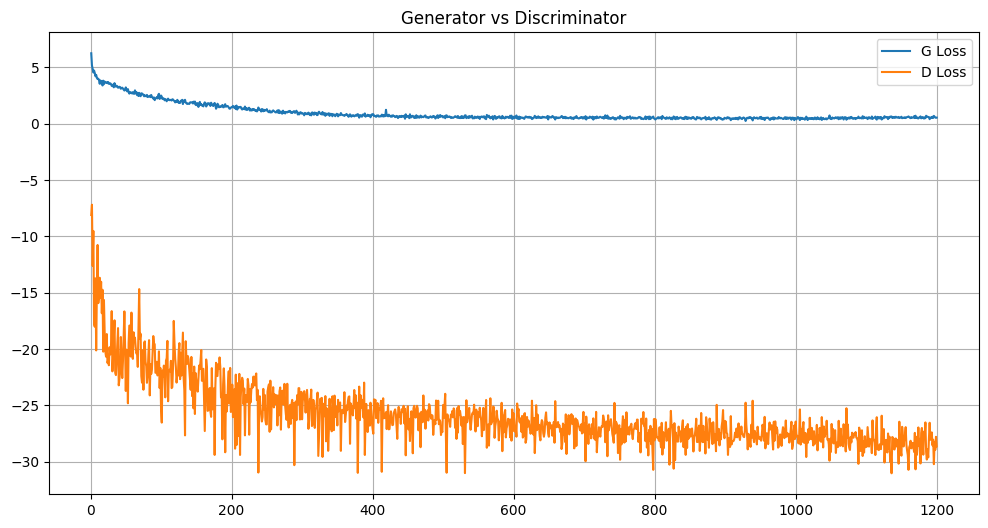

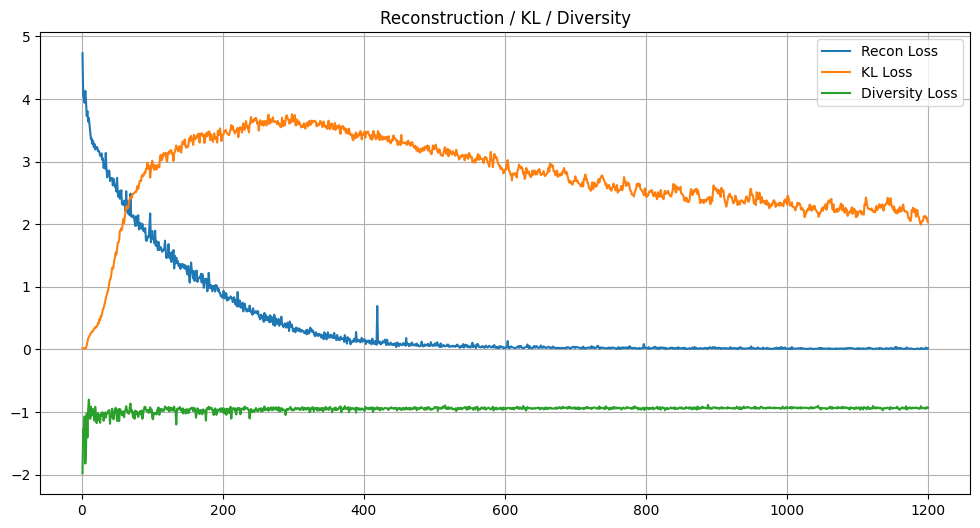

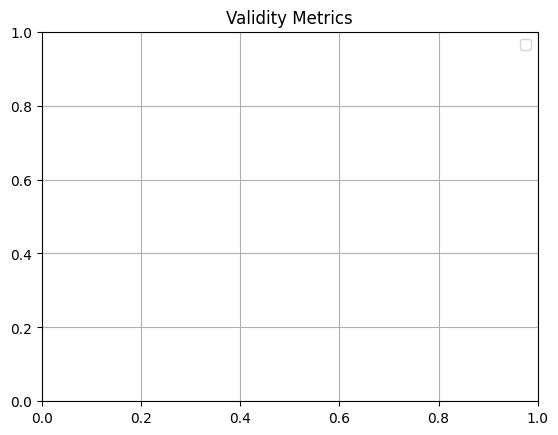

In [68]:
# history_df = pd.DataFrame(history)

history_df.to_csv(

    "/content/drive/MyDrive/India_AI_Final-Set_CVAE/training_history.csv",

    index=False
)

print("\nTraining history saved.")


# ============================================================
# PLOT TRAINING CURVES
# ============================================================

plt.figure(figsize=(12,6))

plt.plot(

    history["epoch"],

    history["g_loss"],

    label="G Loss"
)

plt.plot(

    history["epoch"],

    history["d_loss"],

    label="D Loss"
)

plt.legend()

plt.grid(True)

plt.title("Generator vs Discriminator")

plt.show()


# ============================================================

plt.figure(figsize=(12,6))

plt.plot(

    history["epoch"],

    history["recon_loss"],

    label="Recon Loss"
)

plt.plot(

    history["epoch"],

    history["kl_loss"],

    label="KL Loss"
)

plt.plot(

    history["epoch"],

    history["diversity_loss"],

    label="Diversity Loss"
)

plt.legend()

plt.grid(True)

plt.title("Reconstruction / KL / Diversity")

plt.show()


# ============================================================

# plt.figure(figsize=(12,6))

# plt.plot(

#     history["epoch"],

#     history["smact_validity"],

#     label="SMACT Validity %"
# )

# plt.plot(

#     history["epoch"],

#     history["unique_percent"],

#     label="Unique %"
# )

plt.legend()

plt.grid(True)

plt.title("Validity Metrics")

plt.show()


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

In [69]:
# ============================================================
# SAMPLE GENERATION
# ============================================================

print("\n===================================")
print("GENERATED MATERIALS")
print("===================================")

encoder.eval()

decoder.eval()

for class_idx, condition_name in enumerate(all_conditions):

    print(f"\nCONDITION: {condition_name}")

    condition_vector = torch.zeros(

        1,

        CONDITION_DIM

    ).to(device)

    condition_vector[0, class_idx] = 1

    cond_emb = condition_embedding(
        condition_vector
    )

    for i in range(10):

        z = torch.randn(

            1,

            LATENT_DIM

        ).to(device)

        with torch.no_grad():

            (
                pred_elements,
                pred_fractions,
                pred_occupancy

            ) = decoder(
                z,
                cond_emb
            )

        probs = F.softmax(

            pred_elements / 0.7,

            dim=-1
        )

        pred_ids = torch.argmax(
            probs,
            dim=-1
        )[0]

        formula = ids_to_formula(

            pred_ids,

            pred_fractions[0],

            pred_occupancy[0]
        )

        print("--------------------------------")

        print(f"Generated Formula: {formula}")

print("\nPIPELINE FINISHED")


GENERATED MATERIALS

CONDITION: LzT_LT
--------------------------------
Generated Formula: Sb0.657Co0.311Yb0.031
--------------------------------
Generated Formula: P0.605Cu0.238Ba0.140
--------------------------------
Generated Formula: Sb0.690Co0.288Te0.022
--------------------------------
Generated Formula: Sb0.634Ga0.285Te0.081
--------------------------------
Generated Formula: Sn0.555Ga0.315Ba0.111Sm0.019
--------------------------------
Generated Formula: Sb0.624Mo0.287Ni0.074
--------------------------------
Generated Formula: Sb0.627Co0.247Ba0.106Y0.020
--------------------------------
Generated Formula: Fe0.545Se0.372Ti0.083
--------------------------------
Generated Formula: Sb0.679Co0.254In0.046Ni0.022
--------------------------------
Generated Formula: Sb0.558Zn0.289Si0.153

CONDITION: HzT_LT
--------------------------------
Generated Formula: S0.726Sn0.274
--------------------------------
Generated Formula: Ga0.454S0.351Rb0.195
--------------------------------
Generated 

In [70]:
# ============================================================
# SAMPLE GENERATION
# ============================================================

print("\n===================================")
print("GENERATED MATERIALS")
print("===================================")

encoder.eval()

decoder.eval()

for class_idx, condition_name in enumerate(all_conditions):

    print(f"\nCONDITION: {condition_name}")

    condition_vector = torch.zeros(

        1,

        CONDITION_DIM

    ).to(device)

    condition_vector[0, class_idx] = 1

    cond_emb = condition_embedding(
        condition_vector
    )

    for i in range(10):

        z = torch.randn(

            1,

            LATENT_DIM

        ).to(device)

        with torch.no_grad():

            (
                pred_elements,
                pred_fractions,
                pred_occupancy

            ) = decoder(
                z,
                cond_emb
            )

        probs = F.softmax(

            pred_elements / 0.7,

            dim=-1
        )

        pred_ids = torch.argmax(
            probs,
            dim=-1
        )[0]

        formula = ids_to_formula(

            pred_ids,

            pred_fractions[0],

            pred_occupancy[0]
        )

        print("--------------------------------")

        print(f"Generated Formula: {formula}")

print("\nPIPELINE FINISHED")


GENERATED MATERIALS

CONDITION: LzT_LT
--------------------------------
Generated Formula: Se0.763Te0.163Gd0.074
--------------------------------
Generated Formula: Bi0.540Sn0.286Te0.174
--------------------------------
Generated Formula: Bi0.404Ru0.353Te0.243
--------------------------------
Generated Formula: Sn0.441Ga0.291Ba0.186Ge0.082
--------------------------------
Generated Formula: Sb0.444Sr0.324Sn0.220
--------------------------------
Generated Formula: Bi0.496Ru0.336Sn0.168
--------------------------------
Generated Formula: P0.651Sn0.216Ce0.133
--------------------------------
Generated Formula: Sb0.692Ru0.250La0.032Nd0.026
--------------------------------
Generated Formula: Bi0.372La0.274Cu0.280
--------------------------------
Generated Formula: Sb0.594Ru0.285Ni0.121

CONDITION: HzT_LT
--------------------------------
Generated Formula: As0.401La0.211Sn0.295Rh0.094
--------------------------------
Generated Formula: P0.905O0.092
--------------------------------
Generated


GENERATED MATERIAL ANALYSIS

CONDITION: LzT_LT

--------------------------------
SAMPLE: 1

FORMULA: B0.609Ga0.270Al0.121

SMACT STATUS: INVALID

TOKENS:
['B_0.61', 'Ga_0.27', 'Al_0.12']


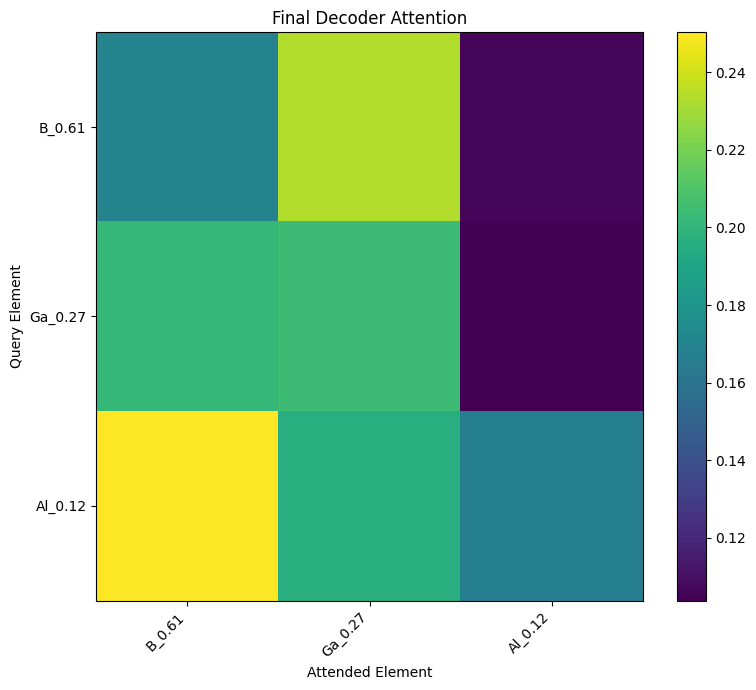


TOP INTERACTIONS
Al_0.12 --> B_0.61 : 0.2503
B_0.61 --> Ga_0.27 : 0.2335
Ga_0.27 --> Ga_0.27 : 0.2043
Ga_0.27 --> B_0.61 : 0.2014
Al_0.12 --> Ga_0.27 : 0.1954
B_0.61 --> B_0.61 : 0.1693
Al_0.12 --> Al_0.12 : 0.1668
B_0.61 --> Al_0.12 : 0.1062
Ga_0.27 --> Al_0.12 : 0.1039

--------------------------------
SAMPLE: 2

FORMULA: Au0.739Mo0.238O0.023

SMACT STATUS: INVALID

TOKENS:
['Au_0.74', 'Mo_0.24', 'O_0.02']


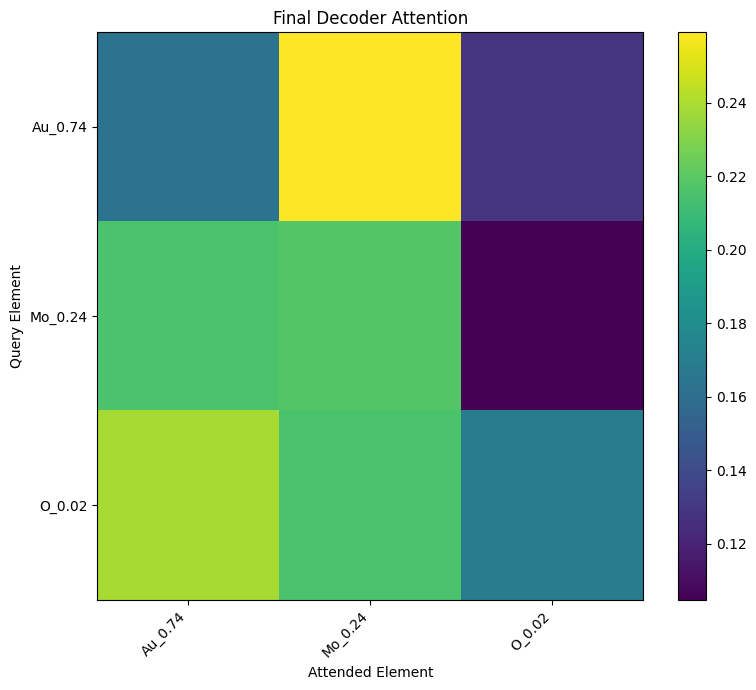


TOP INTERACTIONS
Au_0.74 --> Mo_0.24 : 0.2592
O_0.02 --> Au_0.74 : 0.2391
Mo_0.24 --> Mo_0.24 : 0.2180
O_0.02 --> Mo_0.24 : 0.2157
Mo_0.24 --> Au_0.74 : 0.2152
O_0.02 --> O_0.02 : 0.1693
Au_0.74 --> Au_0.74 : 0.1638
Au_0.74 --> O_0.02 : 0.1283
Mo_0.24 --> O_0.02 : 0.1047

--------------------------------
SAMPLE: 3

FORMULA: Lu0.693Sb0.267Bk0.040

SMACT STATUS: VALID

TOKENS:
['Lu_0.69', 'Sb_0.27', 'Bk_0.04']


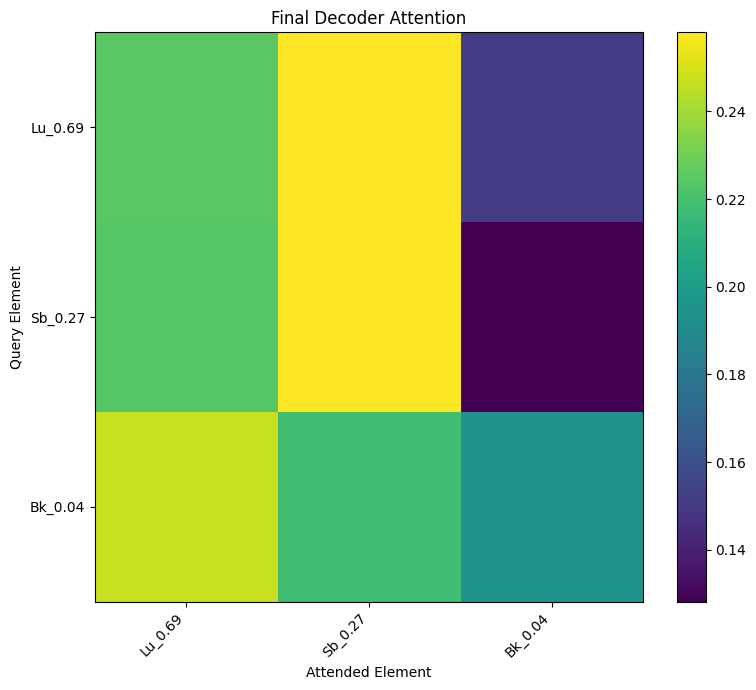


TOP INTERACTIONS
Lu_0.69 --> Sb_0.27 : 0.2580
Sb_0.27 --> Sb_0.27 : 0.2578
Bk_0.04 --> Lu_0.69 : 0.2473
Lu_0.69 --> Lu_0.69 : 0.2250
Sb_0.27 --> Lu_0.69 : 0.2236
Bk_0.04 --> Sb_0.27 : 0.2180
Bk_0.04 --> Bk_0.04 : 0.1954
Lu_0.69 --> Bk_0.04 : 0.1510
Sb_0.27 --> Bk_0.04 : 0.1282

--------------------------------
SAMPLE: 4

FORMULA: Fe0.693W0.254Gd0.053

SMACT STATUS: VALID

TOKENS:
['Fe_0.69', 'W_0.25', 'Gd_0.05']


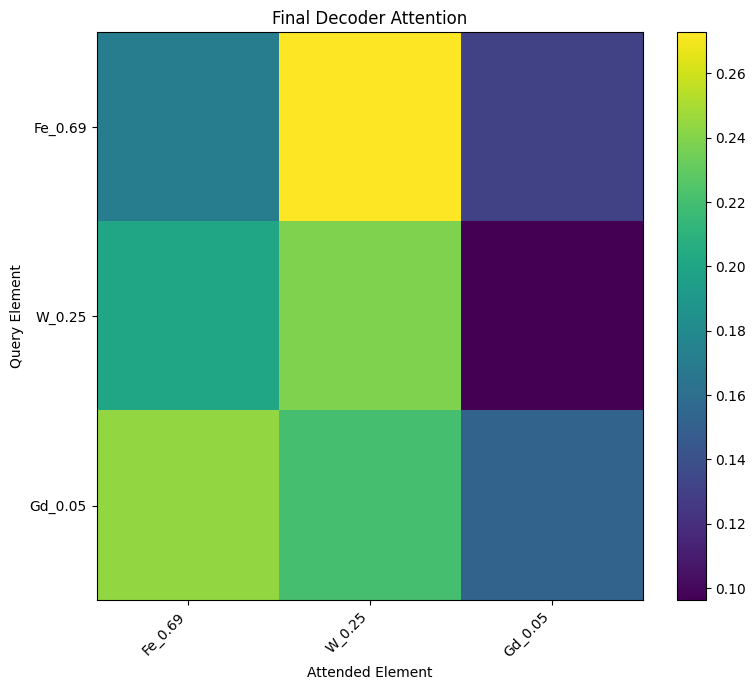


TOP INTERACTIONS
Fe_0.69 --> W_0.25 : 0.2728
Gd_0.05 --> Fe_0.69 : 0.2439
W_0.25 --> W_0.25 : 0.2384
Gd_0.05 --> W_0.25 : 0.2205
W_0.25 --> Fe_0.69 : 0.2005
Fe_0.69 --> Fe_0.69 : 0.1704
Gd_0.05 --> Gd_0.05 : 0.1521
Fe_0.69 --> Gd_0.05 : 0.1311
W_0.25 --> Gd_0.05 : 0.0962

--------------------------------
SAMPLE: 5

FORMULA: At0.636Es0.293Ra0.071

SMACT STATUS: INVALID

TOKENS:
['At_0.64', 'Es_0.29', 'Ra_0.07']


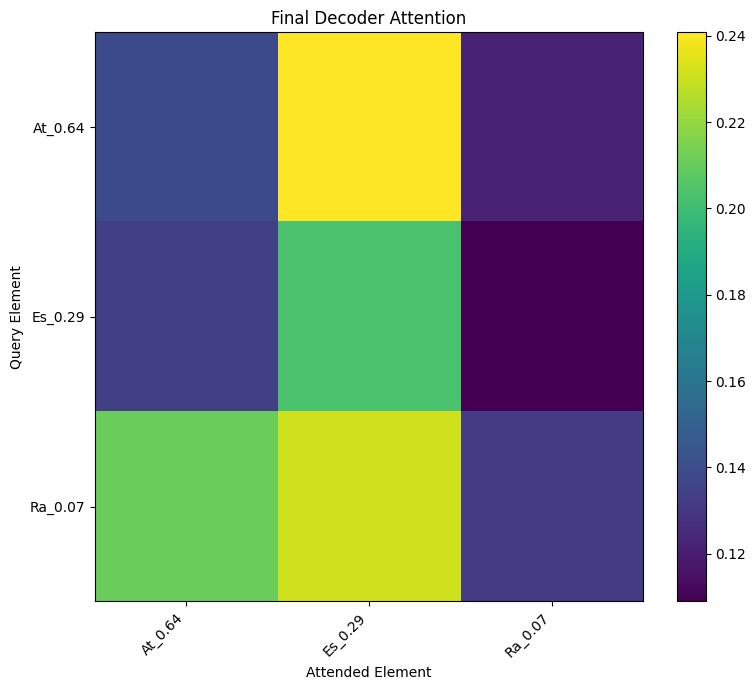


TOP INTERACTIONS
At_0.64 --> Es_0.29 : 0.2408
Ra_0.07 --> Es_0.29 : 0.2313
Ra_0.07 --> At_0.64 : 0.2105
Es_0.29 --> Es_0.29 : 0.2031
At_0.64 --> At_0.64 : 0.1385
Es_0.29 --> At_0.64 : 0.1339
Ra_0.07 --> Ra_0.07 : 0.1323
At_0.64 --> Ra_0.07 : 0.1218
Es_0.29 --> Ra_0.07 : 0.1089

SMACT SUMMARY : LzT_LT
True Count  : 2
False Count : 3
Validity %  : 40.00%

CONDITION: HzT_LT

--------------------------------
SAMPLE: 1

FORMULA: Sn0.625Pd0.239Os0.135

SMACT STATUS: VALID

TOKENS:
['Sn_0.63', 'Pd_0.24', 'Os_0.14']


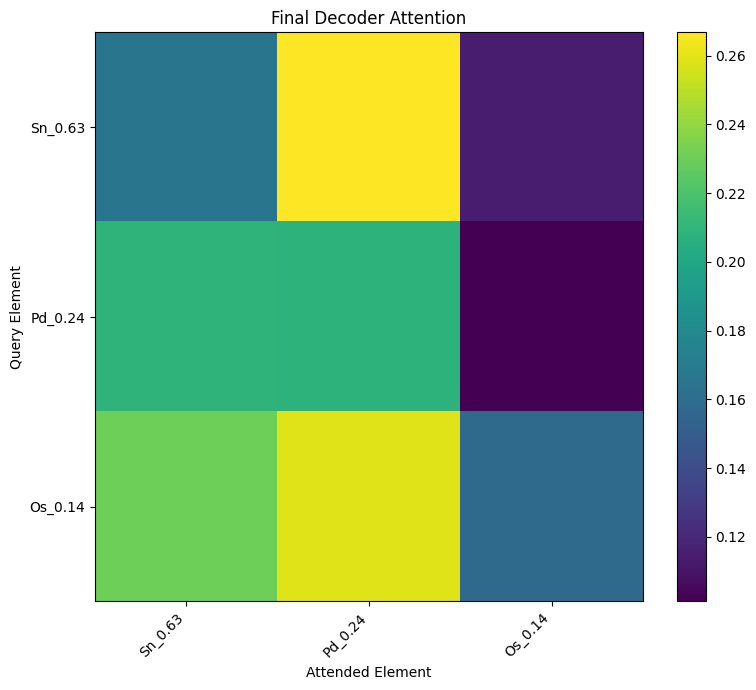


TOP INTERACTIONS
Sn_0.63 --> Pd_0.24 : 0.2668
Os_0.14 --> Pd_0.24 : 0.2585
Os_0.14 --> Sn_0.63 : 0.2303
Pd_0.24 --> Sn_0.63 : 0.2089
Pd_0.24 --> Pd_0.24 : 0.2080
Sn_0.63 --> Sn_0.63 : 0.1654
Os_0.14 --> Os_0.14 : 0.1587
Sn_0.63 --> Os_0.14 : 0.1144
Pd_0.24 --> Os_0.14 : 0.1012

--------------------------------
SAMPLE: 2

FORMULA: Au0.723Sn0.187No0.090

SMACT STATUS: VALID

TOKENS:
['Au_0.72', 'Sn_0.19', 'No_0.09']


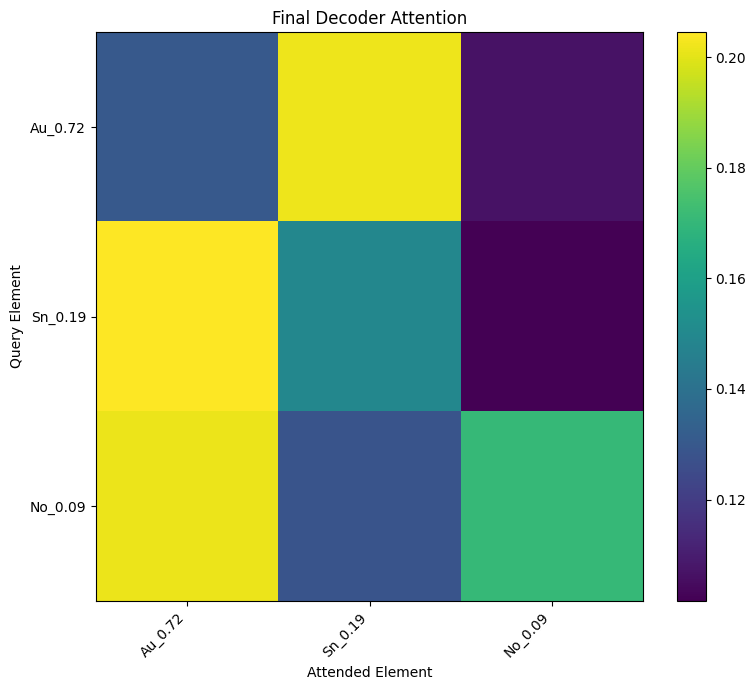


TOP INTERACTIONS
Sn_0.19 --> Au_0.72 : 0.2045
Au_0.72 --> Sn_0.19 : 0.2019
No_0.09 --> Au_0.72 : 0.2016
No_0.09 --> No_0.09 : 0.1705
Sn_0.19 --> Sn_0.19 : 0.1493
Au_0.72 --> Au_0.72 : 0.1306
No_0.09 --> Sn_0.19 : 0.1286
Au_0.72 --> No_0.09 : 0.1068
Sn_0.19 --> No_0.09 : 0.1017

--------------------------------
SAMPLE: 3

FORMULA: Fm0.533Pd0.324F0.143

SMACT STATUS: INVALID

TOKENS:
['Fm_0.53', 'Pd_0.32', 'F_0.14']


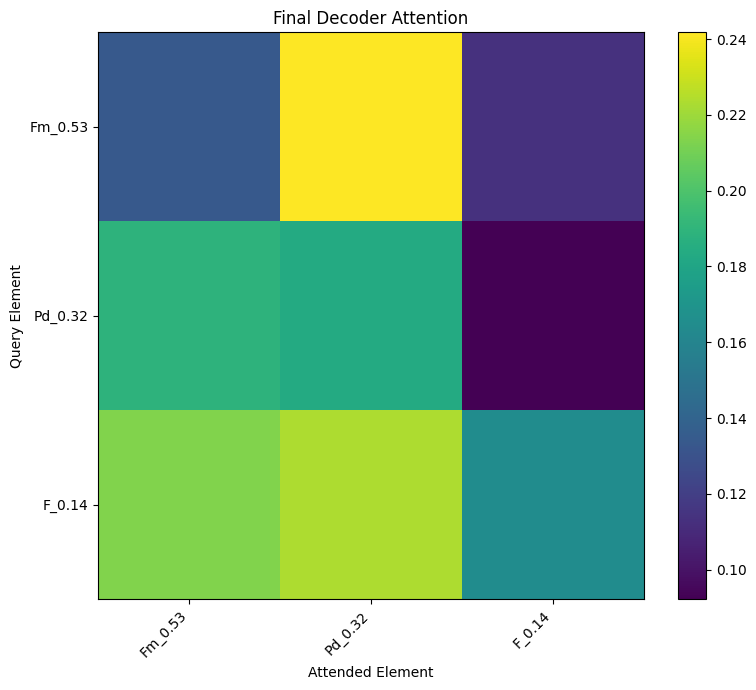


TOP INTERACTIONS
Fm_0.53 --> Pd_0.32 : 0.2418
F_0.14 --> Pd_0.32 : 0.2232
F_0.14 --> Fm_0.53 : 0.2133
Pd_0.32 --> Fm_0.53 : 0.1892
Pd_0.32 --> Pd_0.32 : 0.1836
F_0.14 --> F_0.14 : 0.1648
Fm_0.53 --> Fm_0.53 : 0.1340
Fm_0.53 --> F_0.14 : 0.1136
Pd_0.32 --> F_0.14 : 0.0922

--------------------------------
SAMPLE: 4

FORMULA: Ba0.542Ta0.328Cs0.130

SMACT STATUS: VALID

TOKENS:
['Ba_0.54', 'Ta_0.33', 'Cs_0.13']


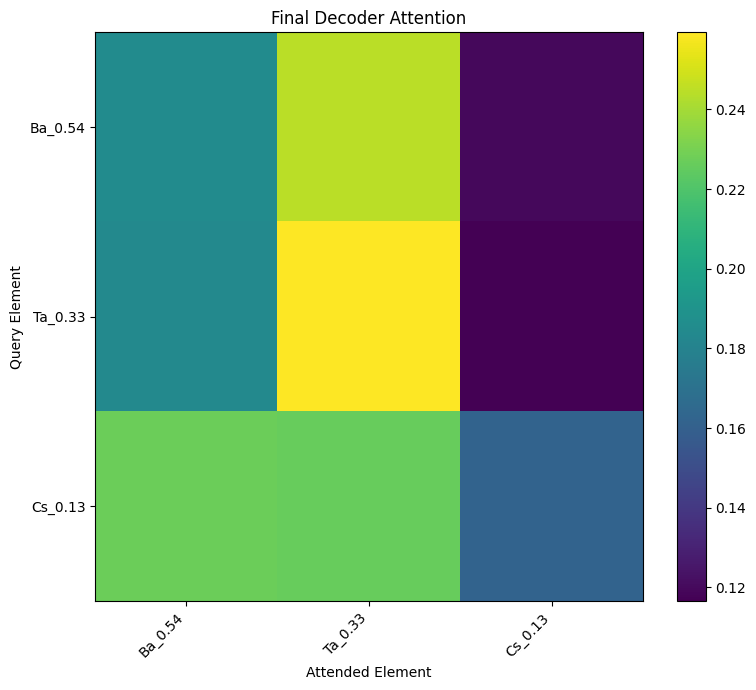


TOP INTERACTIONS
Ta_0.33 --> Ta_0.33 : 0.2593
Ba_0.54 --> Ta_0.33 : 0.2445
Cs_0.13 --> Ba_0.54 : 0.2274
Cs_0.13 --> Ta_0.33 : 0.2260
Ba_0.54 --> Ba_0.54 : 0.1853
Ta_0.33 --> Ba_0.54 : 0.1836
Cs_0.13 --> Cs_0.13 : 0.1618
Ba_0.54 --> Cs_0.13 : 0.1193
Ta_0.33 --> Cs_0.13 : 0.1165

--------------------------------
SAMPLE: 5

FORMULA: Hf0.845Rb0.030Sb0.125

SMACT STATUS: VALID

TOKENS:
['Hf_0.84', 'Rb_0.03', 'Sb_0.13']


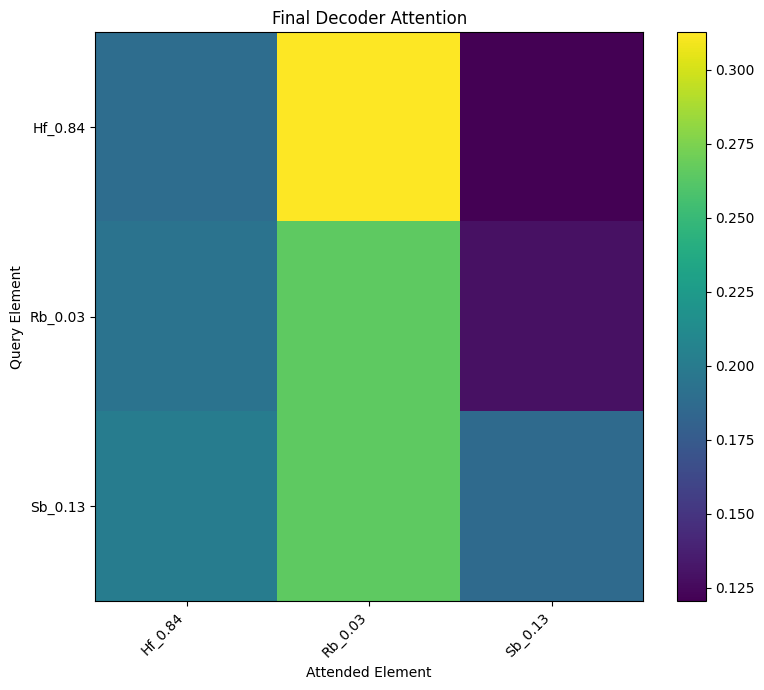


TOP INTERACTIONS
Hf_0.84 --> Rb_0.03 : 0.3127
Sb_0.13 --> Rb_0.03 : 0.2649
Rb_0.03 --> Rb_0.03 : 0.2649
Sb_0.13 --> Hf_0.84 : 0.2009
Rb_0.03 --> Hf_0.84 : 0.1939
Hf_0.84 --> Hf_0.84 : 0.1891
Sb_0.13 --> Sb_0.13 : 0.1867
Rb_0.03 --> Sb_0.13 : 0.1289
Hf_0.84 --> Sb_0.13 : 0.1205

SMACT SUMMARY : HzT_LT
True Count  : 4
False Count : 1
Validity %  : 80.00%

CONDITION: LzT_MT

--------------------------------
SAMPLE: 1

FORMULA: P0.747Zn0.173At0.080

SMACT STATUS: INVALID

TOKENS:
['P_0.75', 'Zn_0.17', 'At_0.08']


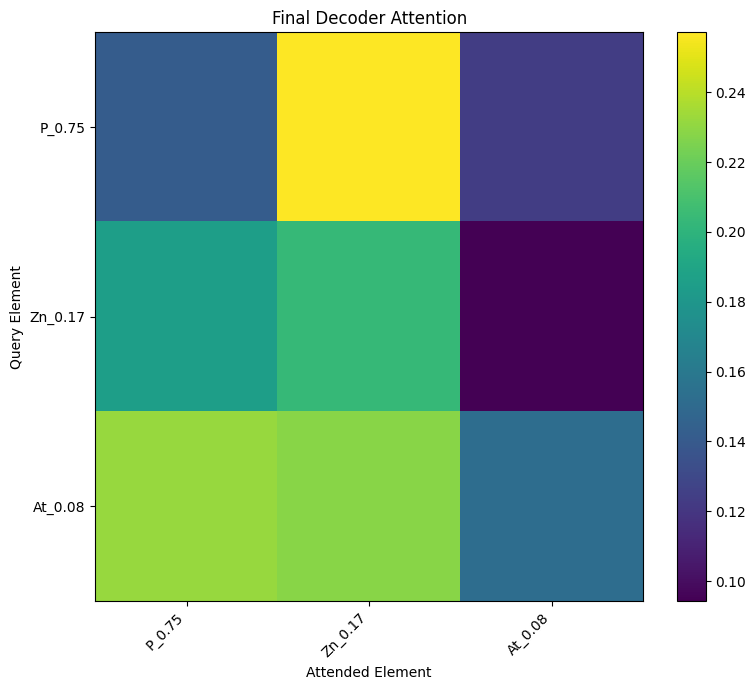


TOP INTERACTIONS
P_0.75 --> Zn_0.17 : 0.2572
At_0.08 --> P_0.75 : 0.2321
At_0.08 --> Zn_0.17 : 0.2279
Zn_0.17 --> Zn_0.17 : 0.2032
Zn_0.17 --> P_0.75 : 0.1855
At_0.08 --> At_0.08 : 0.1524
P_0.75 --> P_0.75 : 0.1418
P_0.75 --> At_0.08 : 0.1237
Zn_0.17 --> At_0.08 : 0.0943

--------------------------------
SAMPLE: 2

FORMULA: La0.521Au0.300Tb0.179

SMACT STATUS: VALID

TOKENS:
['La_0.52', 'Au_0.30', 'Tb_0.18']


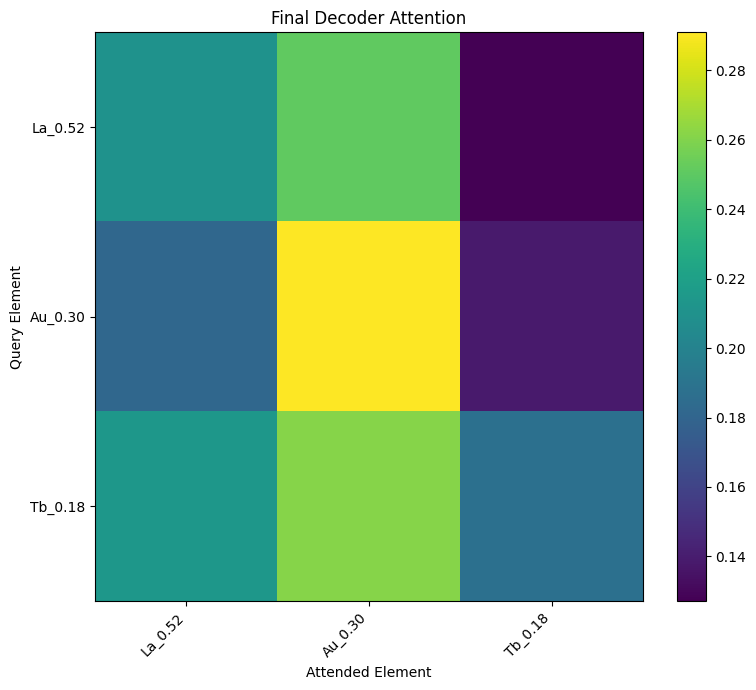


TOP INTERACTIONS
Au_0.30 --> Au_0.30 : 0.2910
Tb_0.18 --> Au_0.30 : 0.2615
La_0.52 --> Au_0.30 : 0.2511
Tb_0.18 --> La_0.52 : 0.2135
La_0.52 --> La_0.52 : 0.2106
Tb_0.18 --> Tb_0.18 : 0.1876
Au_0.30 --> La_0.52 : 0.1817
Au_0.30 --> Tb_0.18 : 0.1392
La_0.52 --> Tb_0.18 : 0.1271

--------------------------------
SAMPLE: 3

FORMULA: Pa0.529S0.271Te0.200

SMACT STATUS: INVALID

TOKENS:
['Pa_0.53', 'S_0.27', 'Te_0.20']


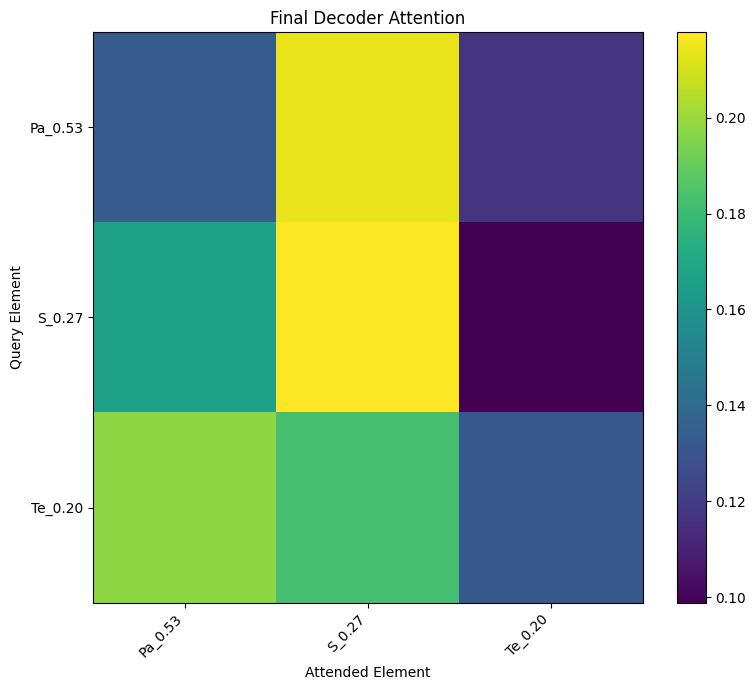


TOP INTERACTIONS
S_0.27 --> S_0.27 : 0.2178
Pa_0.53 --> S_0.27 : 0.2136
Te_0.20 --> Pa_0.53 : 0.1976
Te_0.20 --> S_0.27 : 0.1827
S_0.27 --> Pa_0.53 : 0.1669
Pa_0.53 --> Pa_0.53 : 0.1333
Te_0.20 --> Te_0.20 : 0.1314
Pa_0.53 --> Te_0.20 : 0.1170
S_0.27 --> Te_0.20 : 0.0989

--------------------------------
SAMPLE: 4

FORMULA: Sb0.545Ru0.283Au0.173

SMACT STATUS: VALID

TOKENS:
['Sb_0.54', 'Ru_0.28', 'Au_0.17']


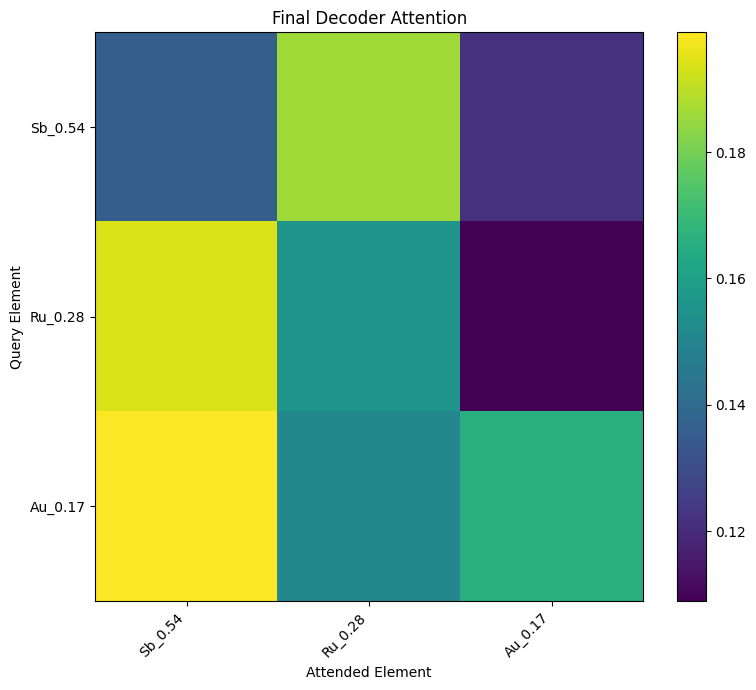


TOP INTERACTIONS
Au_0.17 --> Sb_0.54 : 0.1989
Ru_0.28 --> Sb_0.54 : 0.1942
Sb_0.54 --> Ru_0.28 : 0.1862
Au_0.17 --> Au_0.17 : 0.1657
Ru_0.28 --> Ru_0.28 : 0.1554
Au_0.17 --> Ru_0.28 : 0.1506
Sb_0.54 --> Sb_0.54 : 0.1361
Sb_0.54 --> Au_0.17 : 0.1222
Ru_0.28 --> Au_0.17 : 0.1089

--------------------------------
SAMPLE: 5

FORMULA: Eu0.488Th0.310Pu0.202

SMACT STATUS: VALID

TOKENS:
['Eu_0.49', 'Th_0.31', 'Pu_0.20']


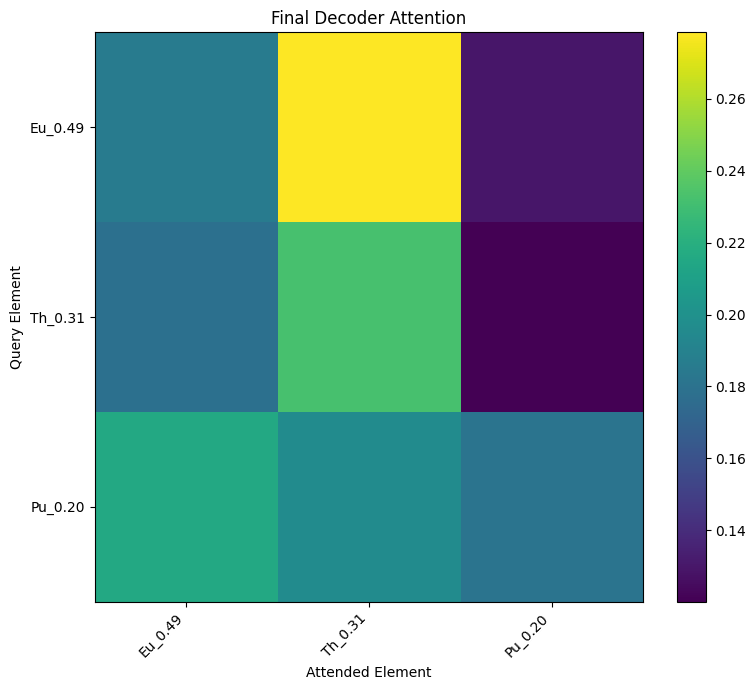


TOP INTERACTIONS
Eu_0.49 --> Th_0.31 : 0.2785
Th_0.31 --> Th_0.31 : 0.2325
Pu_0.20 --> Eu_0.49 : 0.2160
Pu_0.20 --> Th_0.31 : 0.1967
Eu_0.49 --> Eu_0.49 : 0.1861
Pu_0.20 --> Pu_0.20 : 0.1813
Th_0.31 --> Eu_0.49 : 0.1783
Eu_0.49 --> Pu_0.20 : 0.1297
Th_0.31 --> Pu_0.20 : 0.1201

SMACT SUMMARY : LzT_MT
True Count  : 3
False Count : 2
Validity %  : 60.00%

CONDITION: HzT_MT

--------------------------------
SAMPLE: 1

FORMULA: Np0.828Pt0.155Au0.017

SMACT STATUS: VALID

TOKENS:
['Np_0.83', 'Pt_0.15', 'Au_0.02']


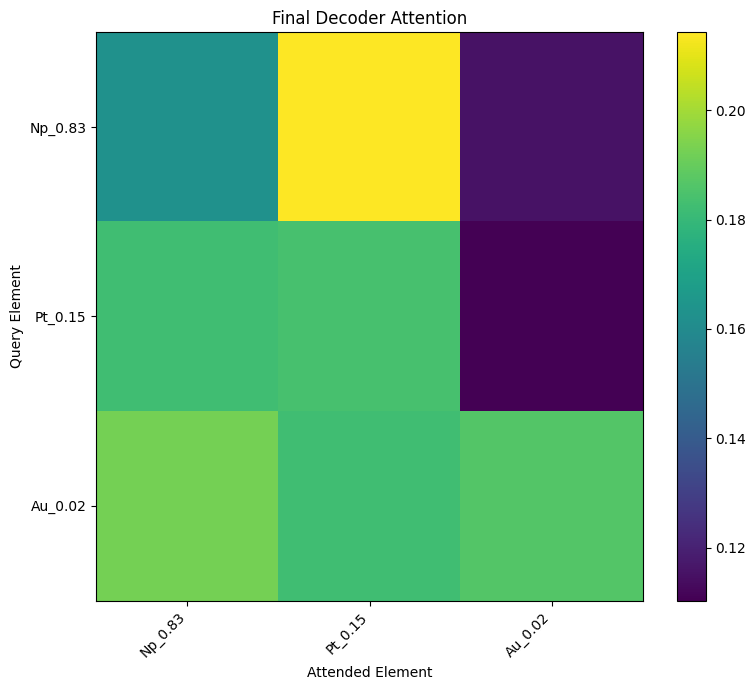


TOP INTERACTIONS
Np_0.83 --> Pt_0.15 : 0.2142
Au_0.02 --> Np_0.83 : 0.1927
Au_0.02 --> Au_0.02 : 0.1863
Pt_0.15 --> Pt_0.15 : 0.1841
Au_0.02 --> Pt_0.15 : 0.1825
Pt_0.15 --> Np_0.83 : 0.1824
Np_0.83 --> Np_0.83 : 0.1630
Np_0.83 --> Au_0.02 : 0.1153
Pt_0.15 --> Au_0.02 : 0.1103

--------------------------------
SAMPLE: 2

FORMULA: S0.712Cf0.251Zr0.037

SMACT STATUS: INVALID

TOKENS:
['S_0.71', 'Cf_0.25', 'Zr_0.04']


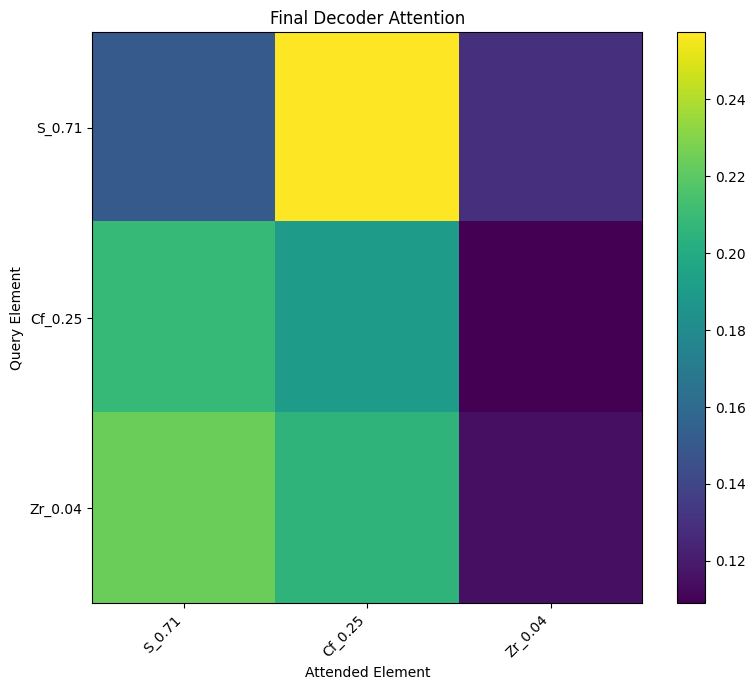


TOP INTERACTIONS
S_0.71 --> Cf_0.25 : 0.2574
Zr_0.04 --> S_0.71 : 0.2240
Cf_0.25 --> S_0.71 : 0.2086
Zr_0.04 --> Cf_0.25 : 0.2054
Cf_0.25 --> Cf_0.25 : 0.1904
S_0.71 --> S_0.71 : 0.1510
S_0.71 --> Zr_0.04 : 0.1295
Zr_0.04 --> Zr_0.04 : 0.1151
Cf_0.25 --> Zr_0.04 : 0.1089

--------------------------------
SAMPLE: 3

FORMULA: B0.488No0.274Pm0.238

SMACT STATUS: INVALID

TOKENS:
['B_0.49', 'No_0.27', 'Pm_0.24']


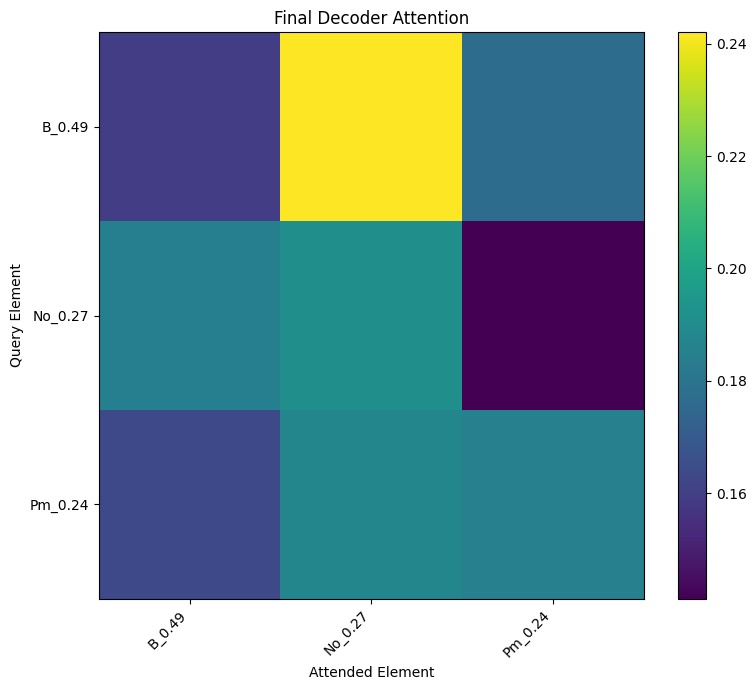


TOP INTERACTIONS
B_0.49 --> No_0.27 : 0.2420
No_0.27 --> No_0.27 : 0.1916
Pm_0.24 --> No_0.27 : 0.1877
Pm_0.24 --> Pm_0.24 : 0.1851
No_0.27 --> B_0.49 : 0.1849
B_0.49 --> Pm_0.24 : 0.1770
Pm_0.24 --> B_0.49 : 0.1635
B_0.49 --> B_0.49 : 0.1595
No_0.27 --> Pm_0.24 : 0.1412

--------------------------------
SAMPLE: 4

FORMULA: Bi0.430Ga0.279Lu0.291

SMACT STATUS: VALID

TOKENS:
['Bi_0.43', 'Ga_0.28', 'Lu_0.29']


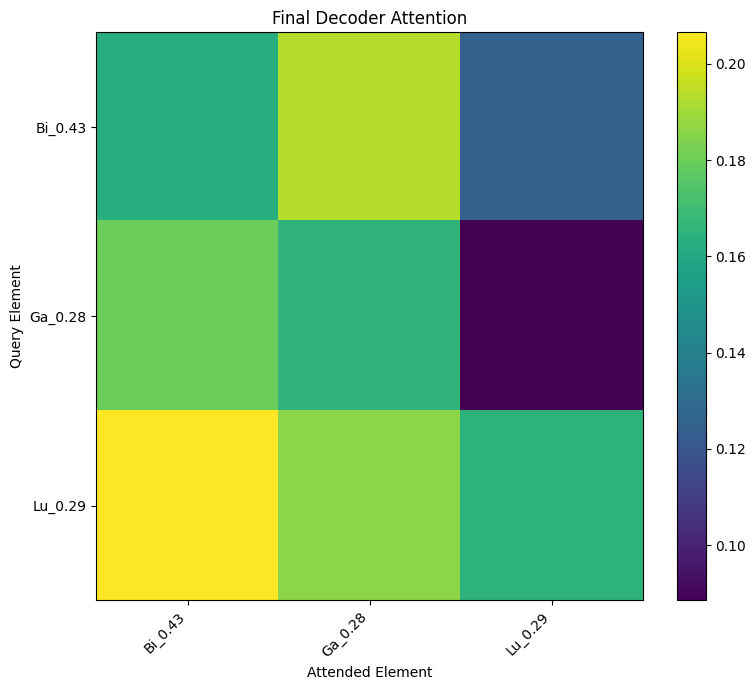


TOP INTERACTIONS
Lu_0.29 --> Bi_0.43 : 0.2065
Bi_0.43 --> Ga_0.28 : 0.1933
Lu_0.29 --> Ga_0.28 : 0.1860
Ga_0.28 --> Bi_0.43 : 0.1800
Ga_0.28 --> Ga_0.28 : 0.1651
Lu_0.29 --> Lu_0.29 : 0.1648
Bi_0.43 --> Bi_0.43 : 0.1624
Bi_0.43 --> Lu_0.29 : 0.1255
Ga_0.28 --> Lu_0.29 : 0.0885

--------------------------------
SAMPLE: 5

FORMULA: Gd0.652Mo0.245Fe0.103

SMACT STATUS: VALID

TOKENS:
['Gd_0.65', 'Mo_0.25', 'Fe_0.10']


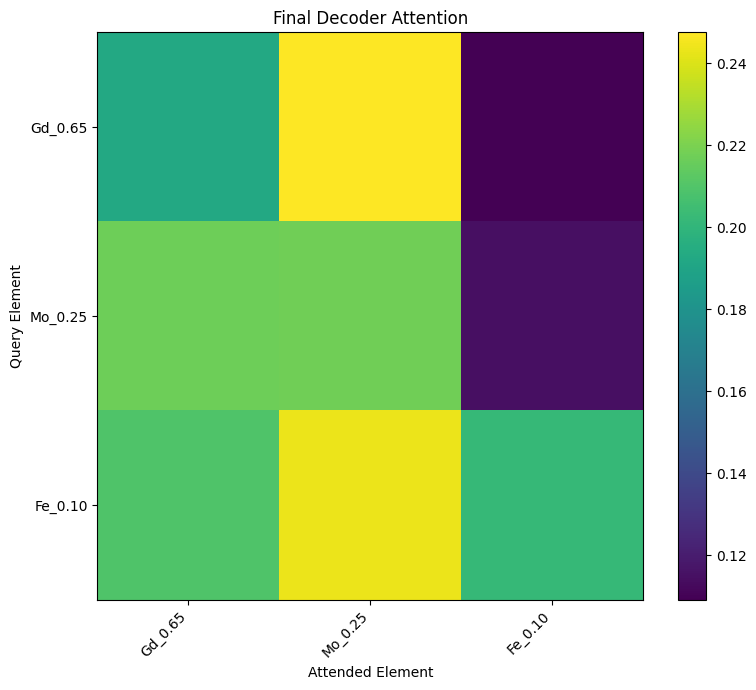


TOP INTERACTIONS
Gd_0.65 --> Mo_0.25 : 0.2475
Fe_0.10 --> Mo_0.25 : 0.2436
Mo_0.25 --> Mo_0.25 : 0.2176
Mo_0.25 --> Gd_0.65 : 0.2168
Fe_0.10 --> Gd_0.65 : 0.2094
Fe_0.10 --> Fe_0.10 : 0.2017
Gd_0.65 --> Gd_0.65 : 0.1924
Mo_0.25 --> Fe_0.10 : 0.1148
Gd_0.65 --> Fe_0.10 : 0.1092

SMACT SUMMARY : HzT_MT
True Count  : 3
False Count : 2
Validity %  : 60.00%

CONDITION: LzT_HT

--------------------------------
SAMPLE: 1

FORMULA: Ti0.551Ta0.327P0.122

SMACT STATUS: INVALID

TOKENS:
['Ti_0.55', 'Ta_0.33', 'P_0.12']


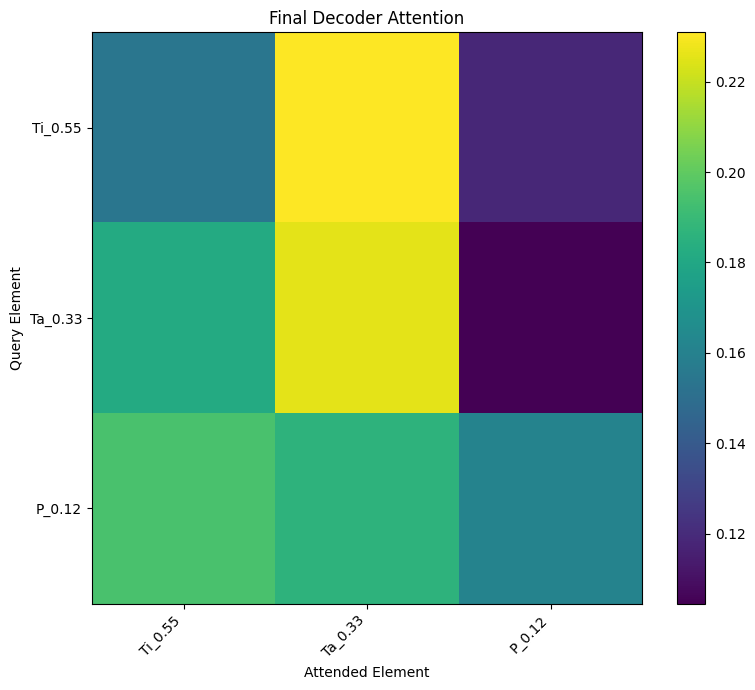


TOP INTERACTIONS
Ti_0.55 --> Ta_0.33 : 0.2309
Ta_0.33 --> Ta_0.33 : 0.2257
P_0.12 --> Ti_0.55 : 0.1945
P_0.12 --> Ta_0.33 : 0.1863
Ta_0.33 --> Ti_0.55 : 0.1818
P_0.12 --> P_0.12 : 0.1612
Ti_0.55 --> Ti_0.55 : 0.1544
Ti_0.55 --> P_0.12 : 0.1185
Ta_0.33 --> P_0.12 : 0.1045

--------------------------------
SAMPLE: 2

FORMULA: S0.534Cs0.311Fr0.155

SMACT STATUS: INVALID

TOKENS:
['S_0.53', 'Cs_0.31', 'Fr_0.15']


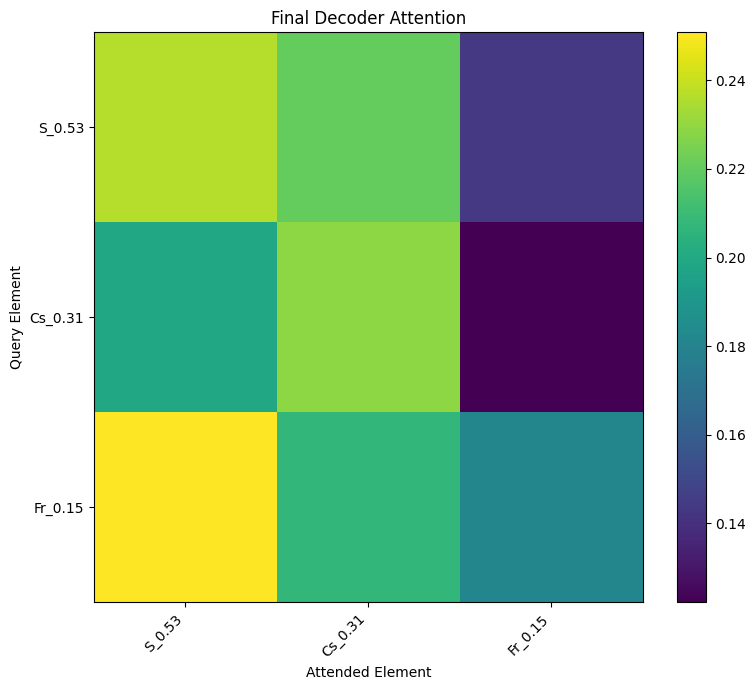


TOP INTERACTIONS
Fr_0.15 --> S_0.53 : 0.2508
S_0.53 --> S_0.53 : 0.2363
Cs_0.31 --> Cs_0.31 : 0.2292
S_0.53 --> Cs_0.31 : 0.2204
Fr_0.15 --> Cs_0.31 : 0.2073
Cs_0.31 --> S_0.53 : 0.1989
Fr_0.15 --> Fr_0.15 : 0.1810
S_0.53 --> Fr_0.15 : 0.1434
Cs_0.31 --> Fr_0.15 : 0.1222

--------------------------------
SAMPLE: 3

FORMULA: In0.596Cu0.404

SMACT STATUS: VALID

TOKENS:
['In_0.60', 'Cu_0.26', 'Cu_0.14']


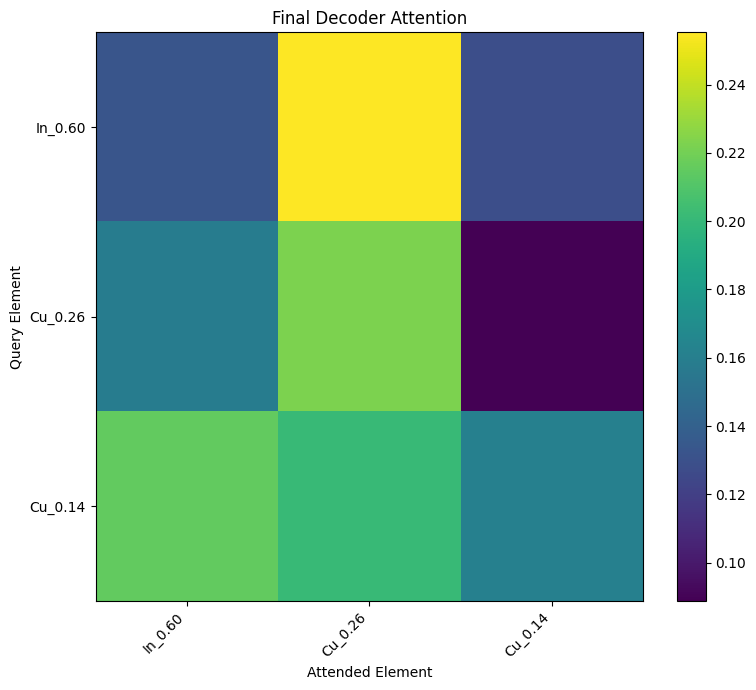


TOP INTERACTIONS
In_0.60 --> Cu_0.26 : 0.2553
Cu_0.26 --> Cu_0.26 : 0.2225
Cu_0.14 --> In_0.60 : 0.2152
Cu_0.14 --> Cu_0.26 : 0.2009
Cu_0.14 --> Cu_0.14 : 0.1612
Cu_0.26 --> In_0.60 : 0.1588
In_0.60 --> In_0.60 : 0.1329
In_0.60 --> Cu_0.14 : 0.1288
Cu_0.26 --> Cu_0.14 : 0.0887

--------------------------------
SAMPLE: 4

FORMULA: Sm0.478I0.329F0.193

SMACT STATUS: INVALID

TOKENS:
['Sm_0.48', 'I_0.33', 'F_0.19']


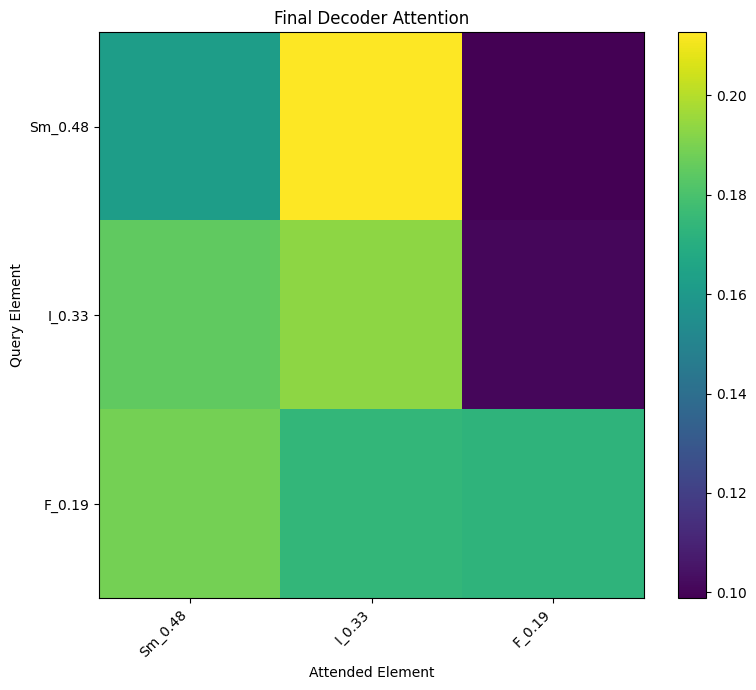


TOP INTERACTIONS
Sm_0.48 --> I_0.33 : 0.2127
I_0.33 --> I_0.33 : 0.1933
F_0.19 --> Sm_0.48 : 0.1887
I_0.33 --> Sm_0.48 : 0.1847
F_0.19 --> I_0.33 : 0.1744
F_0.19 --> F_0.19 : 0.1730
Sm_0.48 --> Sm_0.48 : 0.1621
I_0.33 --> F_0.19 : 0.1008
Sm_0.48 --> F_0.19 : 0.0988

--------------------------------
SAMPLE: 5

FORMULA: Sm0.666Ho0.334

SMACT STATUS: VALID

TOKENS:
['Sm_0.65', 'Ho_0.33']


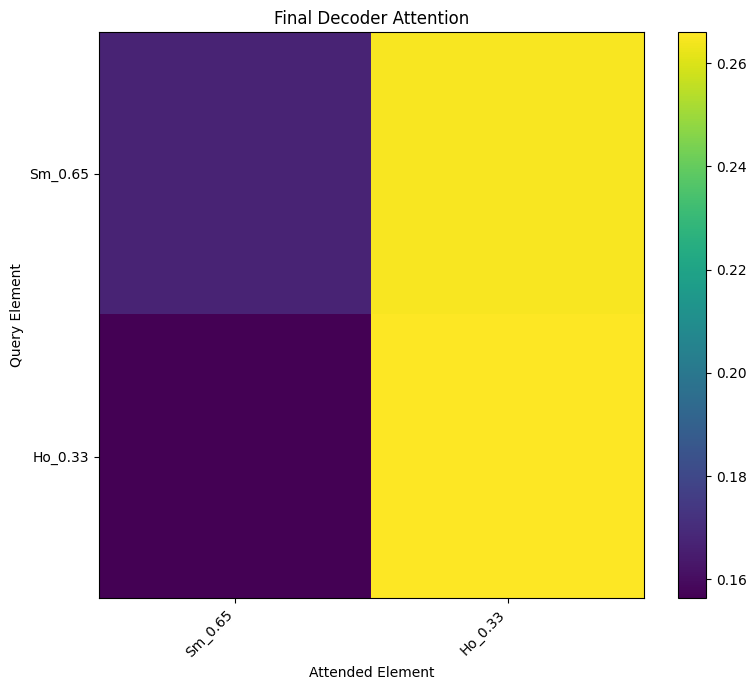


TOP INTERACTIONS
Ho_0.33 --> Ho_0.33 : 0.2660
Sm_0.65 --> Ho_0.33 : 0.2649
Sm_0.65 --> Sm_0.65 : 0.1672
Ho_0.33 --> Sm_0.65 : 0.1563

SMACT SUMMARY : LzT_HT
True Count  : 2
False Count : 3
Validity %  : 40.00%

CONDITION: HzT_HT

--------------------------------
SAMPLE: 1

FORMULA: Es0.487Ag0.321No0.192

SMACT STATUS: VALID

TOKENS:
['Es_0.49', 'Ag_0.32', 'No_0.19']


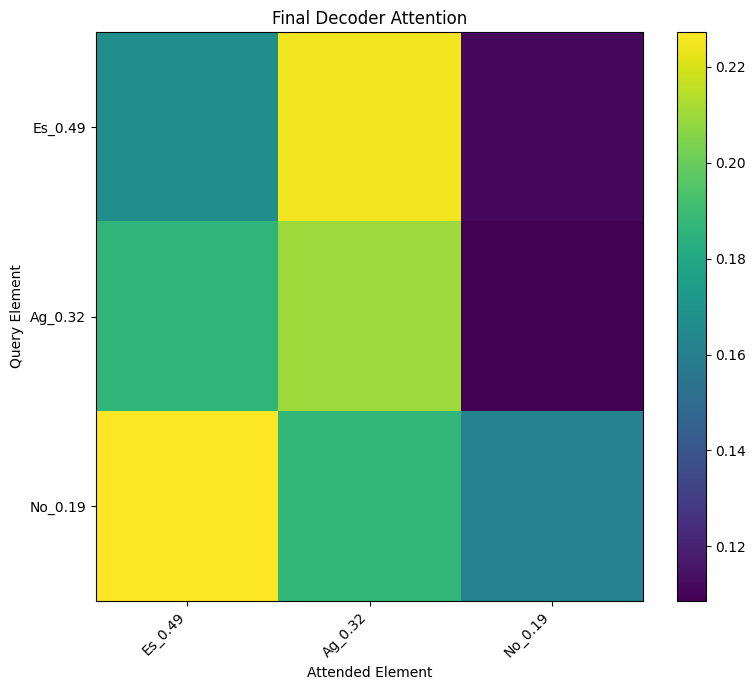


TOP INTERACTIONS
No_0.19 --> Es_0.49 : 0.2272
Es_0.49 --> Ag_0.32 : 0.2251
Ag_0.32 --> Ag_0.32 : 0.2097
No_0.19 --> Ag_0.32 : 0.1870
Ag_0.32 --> Es_0.49 : 0.1861
Es_0.49 --> Es_0.49 : 0.1672
No_0.19 --> No_0.19 : 0.1614
Es_0.49 --> No_0.19 : 0.1113
Ag_0.32 --> No_0.19 : 0.1086

--------------------------------
SAMPLE: 2

FORMULA: Sm0.514Tl0.257P0.228

SMACT STATUS: INVALID

TOKENS:
['Sm_0.51', 'Tl_0.26', 'P_0.23']


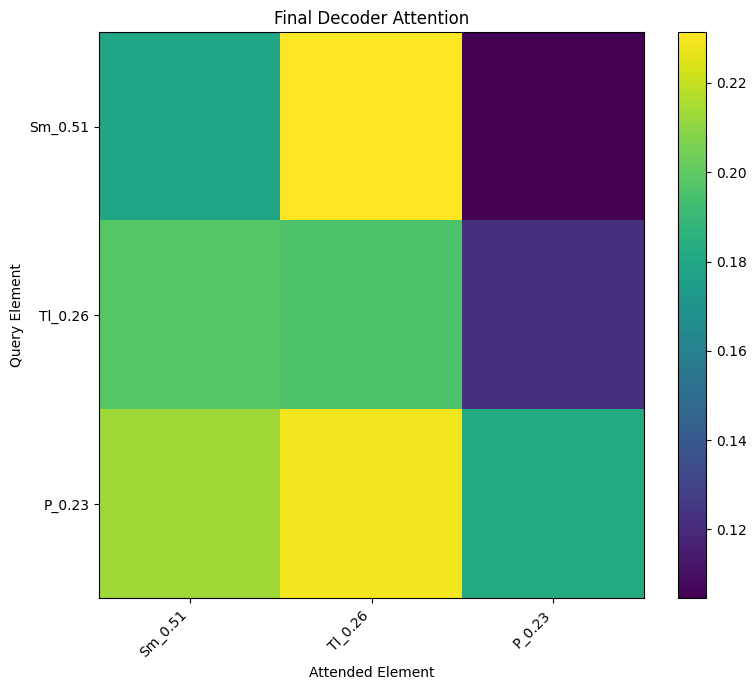


TOP INTERACTIONS
Sm_0.51 --> Tl_0.26 : 0.2313
P_0.23 --> Tl_0.26 : 0.2293
P_0.23 --> Sm_0.51 : 0.2134
Tl_0.26 --> Sm_0.51 : 0.1977
Tl_0.26 --> Tl_0.26 : 0.1961
P_0.23 --> P_0.23 : 0.1823
Sm_0.51 --> Sm_0.51 : 0.1789
Tl_0.26 --> P_0.23 : 0.1219
Sm_0.51 --> P_0.23 : 0.1045

--------------------------------
SAMPLE: 3

FORMULA: N0.425Rb0.305Se0.270

SMACT STATUS: INVALID

TOKENS:
['N_0.42', 'Rb_0.31', 'Se_0.27']


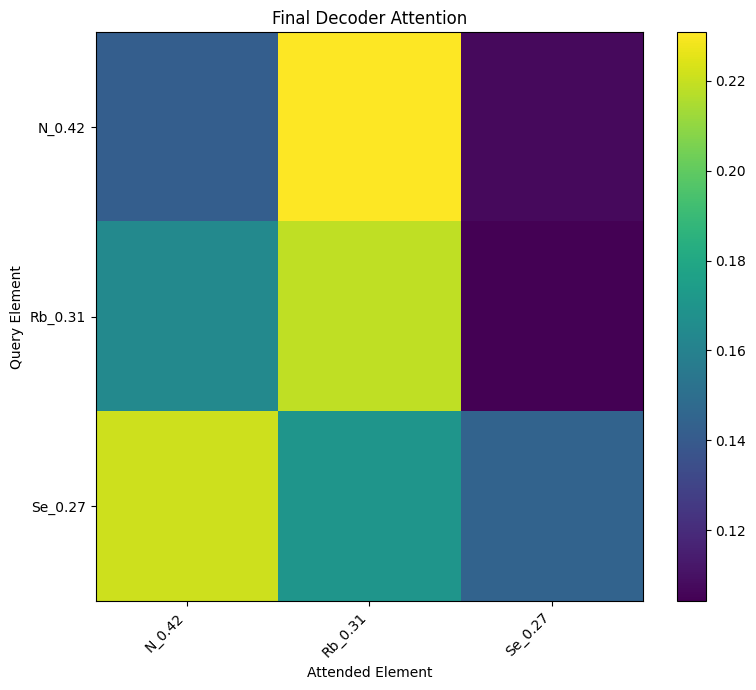


TOP INTERACTIONS
N_0.42 --> Rb_0.31 : 0.2308
Se_0.27 --> N_0.42 : 0.2210
Rb_0.31 --> Rb_0.31 : 0.2188
Se_0.27 --> Rb_0.31 : 0.1701
Rb_0.31 --> N_0.42 : 0.1639
Se_0.27 --> Se_0.27 : 0.1443
N_0.42 --> N_0.42 : 0.1419
N_0.42 --> Se_0.27 : 0.1073
Rb_0.31 --> Se_0.27 : 0.1042

--------------------------------
SAMPLE: 4

FORMULA: Cl0.689Be0.262Pd0.049

SMACT STATUS: INVALID

TOKENS:
['Cl_0.69', 'Be_0.26', 'Pd_0.05']


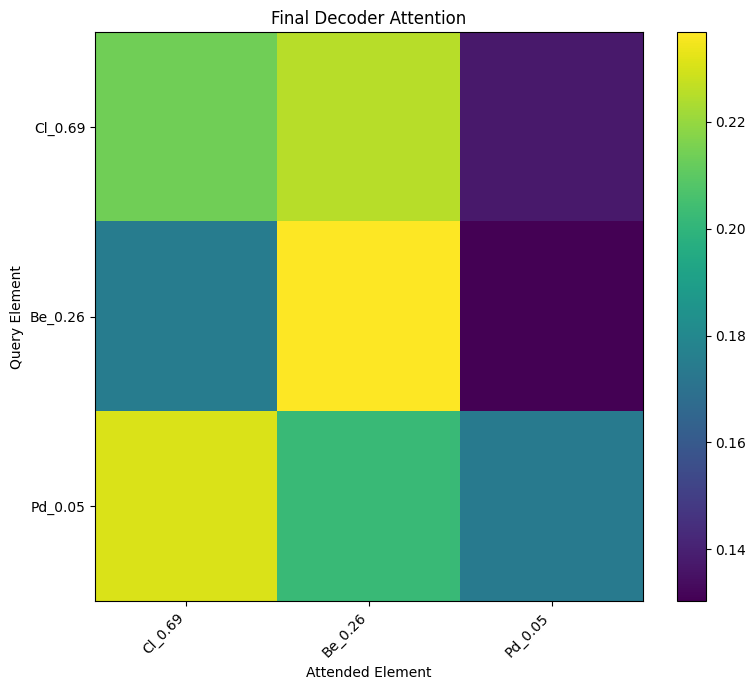


TOP INTERACTIONS
Be_0.26 --> Be_0.26 : 0.2367
Pd_0.05 --> Cl_0.69 : 0.2308
Cl_0.69 --> Be_0.26 : 0.2252
Cl_0.69 --> Cl_0.69 : 0.2135
Pd_0.05 --> Be_0.26 : 0.2024
Be_0.26 --> Cl_0.69 : 0.1751
Pd_0.05 --> Pd_0.05 : 0.1737
Cl_0.69 --> Pd_0.05 : 0.1375
Be_0.26 --> Pd_0.05 : 0.1303

--------------------------------
SAMPLE: 5

FORMULA: Si0.698Pb0.221Br0.081

SMACT STATUS: INVALID

TOKENS:
['Si_0.70', 'Pb_0.22', 'Br_0.08']


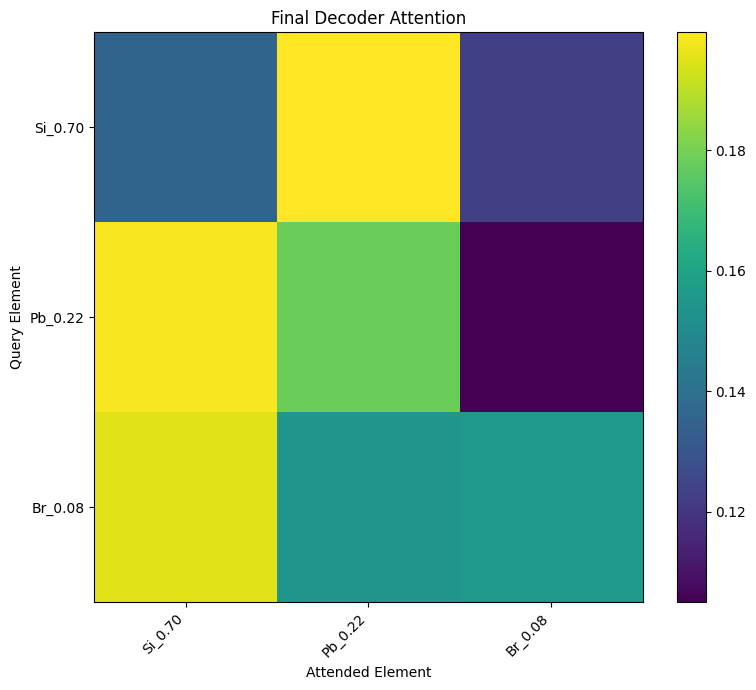


TOP INTERACTIONS
Si_0.70 --> Pb_0.22 : 0.1996
Pb_0.22 --> Si_0.70 : 0.1986
Br_0.08 --> Si_0.70 : 0.1954
Pb_0.22 --> Pb_0.22 : 0.1784
Br_0.08 --> Br_0.08 : 0.1560
Br_0.08 --> Pb_0.22 : 0.1544
Si_0.70 --> Si_0.70 : 0.1355
Si_0.70 --> Br_0.08 : 0.1228
Pb_0.22 --> Br_0.08 : 0.1050

SMACT SUMMARY : HzT_HT
True Count  : 1
False Count : 4
Validity %  : 20.00%

FINAL SUMMARY
Generated : 30
Valid     : 15
Invalid   : 15
Validity % : 50.00

CSV SAVED

VISUALIZING LATENT SPACE


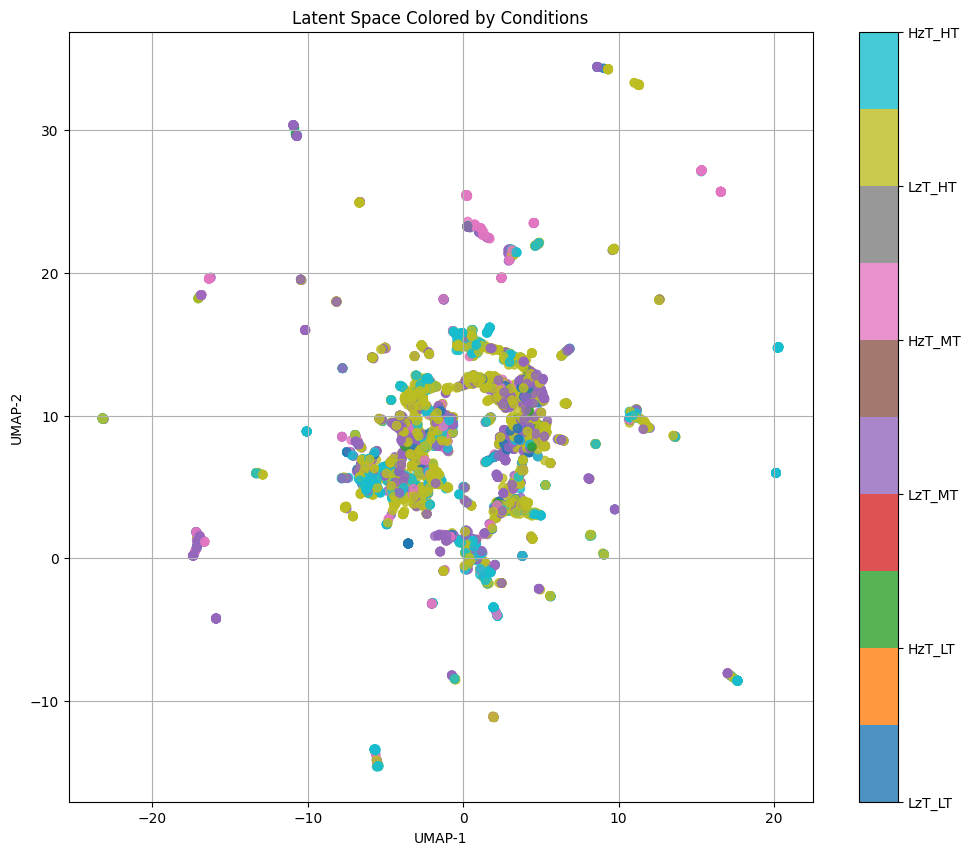

In [72]:
# ============================================================
# SMACT + FINAL ATTENTION + LATENT SPACE VISUALIZATION
# ============================================================

import umap
import pandas as pd
from smact.screening import smact_validity

# ============================================================
# SETTINGS
# ============================================================

TEMPERATURE = 10
TOP_K_ELEMENTS = 3
NUM_SAMPLES = 5

# ============================================================
# TOKEN EXTRACTION
# ============================================================

def get_formula_tokens(

    ids,
    fractions,
    occupancy
):

    tokens = []

    for idx, frac, occ in zip(

        ids,
        fractions,
        occupancy
    ):

        idx = idx.item()

        frac = frac.item()

        occ = occ.item()

        if idx == 0:
            continue

        if occ < 0.5:
            continue

        if frac < 0.01:
            continue

        symbol = idx_to_element[idx]

        token = f"{symbol}_{frac:.2f}"

        tokens.append(token)

    return tokens


# ============================================================
# FORMULA GENERATION
# ============================================================

def ids_to_formula(

    pred_ids,
    fractions,
    occupancy
):

    composition_dict = {}

    for idx, frac, occ in zip(

        pred_ids,
        fractions,
        occupancy
    ):

        idx = idx.item()
        frac = frac.item()
        occ = occ.item()

        if idx == 0:
            continue

        if occ < 0.5:
            continue

        if frac < 0.01:
            continue

        symbol = idx_to_element[idx]

        if symbol not in composition_dict:

            composition_dict[symbol] = 0.0

        composition_dict[symbol] += frac

    total = sum(composition_dict.values())

    if total == 0:
        return None

    for k in composition_dict:

        composition_dict[k] /= total

    formula = ""

    for el, frac in composition_dict.items():

        formula += f"{el}{frac:.3f}"

    return formula


# ============================================================
# SMACT VALIDATION
# ============================================================

def check_smact_validity(formula):

    try:

        comp = Composition(formula)

        reduced_formula = comp.reduced_formula

        valid = smact_validity(
            reduced_formula
        )

        return valid

    except:

        return False


# ============================================================
# FINAL ATTENTION VISUALIZATION
# ============================================================

def visualize_decoder_attention(
    decoder,
    tokens
):

    all_attn = []

    # ========================================================
    # COLLECT SELF ATTENTION
    # ========================================================

    for layer in decoder.layers:

        attn = layer.self_attn.mab.last_attention

        if attn is not None:

            attn = attn[0].mean(0)

            all_attn.append(attn)

    if len(all_attn) == 0:
        return

    # ========================================================
    # AGGREGATE ATTENTION
    # ========================================================

    final_attn = torch.stack(
        all_attn
    ).mean(0)

    final_attn = (
        final_attn
        .detach()
        .cpu()
        .numpy()
    )

    n = len(tokens)

    final_attn = final_attn[:n, :n]

    # ========================================================
    # PLOT
    # ========================================================

    plt.figure(figsize=(8,7))

    plt.imshow(

        final_attn,

        cmap="viridis",

        aspect="auto"
    )

    plt.colorbar()

    plt.xticks(

        range(n),

        tokens,

        rotation=45,

        ha="right"
    )

    plt.yticks(

        range(n),

        tokens
    )

    plt.xlabel("Attended Element")

    plt.ylabel("Query Element")

    plt.title(
        "Final Decoder Attention"
    )

    plt.tight_layout()

    plt.show()

    # ========================================================
    # INTERACTIONS
    # ========================================================

    interactions = []

    for i in range(n):

        for j in range(n):

            interactions.append(

                (
                    tokens[i],
                    tokens[j],
                    final_attn[i,j]
                )
            )

    interactions = sorted(

        interactions,

        key=lambda x: x[2],

        reverse=True
    )

    print("\n================================")
    print("TOP INTERACTIONS")
    print("================================")

    for src, tgt, val in interactions[:10]:

        print(
            f"{src} --> {tgt} : "
            f"{val:.4f}"
        )


# ============================================================
# LATENT SPACE VISUALIZATION
# ============================================================

def visualize_latent_space(

    encoder,
    condition_embedding,
    train_loader
):

    encoder.eval()

    latent_vectors = []
    latent_labels = []

    with torch.no_grad():

        for batch in train_loader:

            (
                element_ids,
                fractions,
                occupancy_gt,
                condition

            ) = batch

            element_ids = element_ids.to(
                device,
                non_blocking=True
            )

            fractions = fractions.to(
                device,
                non_blocking=True
            )

            condition = condition.to(
                device,
                non_blocking=True
            )

            edm = edm_builder(
                element_ids,
                fractions
            )

            cond_emb = condition_embedding(
                condition
            )

            mu, _ = encoder(
                edm,
                cond_emb
            )

            latent_vectors.append(
                mu.detach().cpu()
            )

            labels = torch.argmax(
                condition,
                dim=1
            )

            latent_labels.append(
                labels.cpu()
            )

    latent_vectors = torch.cat(
        latent_vectors,
        dim=0
    )

    latent_labels = torch.cat(
        latent_labels,
        dim=0
    )

    # ========================================================
    # UMAP
    # ========================================================

    reducer = umap.UMAP(

        n_neighbors=20,

        min_dist=0.1,

        metric="cosine",

        random_state=42
    )

    embedding = reducer.fit_transform(
        latent_vectors.numpy()
    )

    # ========================================================
    # PLOT
    # ========================================================

    plt.figure(figsize=(12,10))

    scatter = plt.scatter(

        embedding[:,0],

        embedding[:,1],

        c=latent_labels.numpy(),

        cmap="tab10",

        alpha=0.8
    )

    cbar = plt.colorbar(scatter)

    cbar.set_ticks(
        range(len(all_conditions))
    )

    cbar.set_ticklabels(
        all_conditions
    )

    plt.title(
        "Latent Space Colored by Conditions"
    )

    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")

    plt.grid(True)

    plt.show()


# ============================================================
# COMPLETE GENERATED MATERIAL ANALYSIS
# ============================================================

print("\n===================================")
print("GENERATED MATERIAL ANALYSIS")
print("===================================")

encoder.eval()
decoder.eval()

generated_formulas = []
valid_formulas = []
invalid_formulas = []

generated_data = []

# ============================================================
# ENABLE ATTENTION STORAGE
# ============================================================

for layer in decoder.layers:

    layer.cross.store_attention = True

    layer.self_attn.mab.store_attention = True

# ============================================================
# GENERATE
# ============================================================

for class_idx, condition_name in enumerate(all_conditions):

    print("\n===================================")
    print(f"CONDITION: {condition_name}")
    print("===================================")

    condition_vector = torch.zeros(

        1,
        CONDITION_DIM

    ).to(device)

    condition_vector[0, class_idx] = 1

    cond_emb = condition_embedding(
        condition_vector
    )

    true_count = 0
    false_count = 0

    # ========================================================
    # SAMPLE GENERATION
    # ========================================================

    for i in range(NUM_SAMPLES):

        print("\n--------------------------------")
        print(f"SAMPLE: {i+1}")

        # ====================================================
        # LATENT
        # ====================================================

        z = torch.randn(

            1,
            LATENT_DIM

        ).to(device)

        with torch.no_grad():

            (
                pred_elements,
                pred_fractions,
                pred_occupancy

            ) = decoder(
                z,
                cond_emb
            )

        # ====================================================
        # TEMPERATURE SOFTMAX
        # ====================================================

        probs = F.softmax(

            pred_elements / TEMPERATURE,

            dim=-1
        )

        # ====================================================
        # STOCHASTIC SAMPLING
        # ====================================================

        sampled_ids = []

        for pos in range(probs.shape[1]):

            sampled_id = torch.multinomial(

                probs[0, pos],

                num_samples=1
            )

            sampled_ids.append(sampled_id)

        pred_ids = torch.cat(sampled_ids)

        # ====================================================
        # TOP-K OCCUPANCY
        # ====================================================

        occupancy_scores = pred_occupancy[0]

        topk_indices = torch.topk(

            occupancy_scores,

            k=min(
                TOP_K_ELEMENTS,
                len(occupancy_scores)
            )

        ).indices

        occupancy_mask = torch.zeros_like(
            occupancy_scores
        )

        occupancy_mask[topk_indices] = 1.0

        # ====================================================
        # FILTER FRACTIONS
        # ====================================================

        filtered_fractions = (

            pred_fractions[0] *
            occupancy_mask
        )

        filtered_fractions = (

            filtered_fractions /
            (filtered_fractions.sum() + 1e-8)
        )

        # ====================================================
        # FORMULA
        # ====================================================

        formula = ids_to_formula(

            pred_ids,

            filtered_fractions,

            occupancy_mask
        )

        if formula is None:
            continue

        generated_formulas.append(
            formula
        )

        print(f"\nFORMULA: {formula}")

        # ====================================================
        # SMACT
        # ====================================================

        valid = check_smact_validity(
            formula
        )

        if valid:

            valid_formulas.append(
                formula
            )

            true_count += 1

            print("\nSMACT STATUS: VALID")

        else:

            invalid_formulas.append(
                formula
            )

            false_count += 1

            print("\nSMACT STATUS: INVALID")

        # ====================================================
        # SAVE
        # ====================================================

        generated_data.append({

            "Condition": condition_name,
            "Formula": formula,
            "SMACT_Valid": valid

        })

        # ====================================================
        # TOKENS
        # ====================================================

        tokens = get_formula_tokens(

            pred_ids,

            filtered_fractions,

            occupancy_mask
        )

        print("\nTOKENS:")
        print(tokens)

        # ====================================================
        # ATTENTION
        # ====================================================

        visualize_decoder_attention(

            decoder,

            tokens
        )

    # ========================================================
    # CONDITION SUMMARY
    # ========================================================

    total = true_count + false_count

    if total > 0:

        print("\n================================")
        print(f"SMACT SUMMARY : {condition_name}")
        print("================================")

        print(f"True Count  : {true_count}")
        print(f"False Count : {false_count}")

        print(
            f"Validity %  : "
            f"{100 * true_count / total:.2f}%"
        )

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n===================================")
print("FINAL SUMMARY")
print("===================================")

print(
    f"Generated : {len(generated_formulas)}"
)

print(
    f"Valid     : {len(valid_formulas)}"
)

print(
    f"Invalid   : {len(invalid_formulas)}"
)

if len(generated_formulas) > 0:

    print(
        f"Validity % : "
        f"{100 * len(valid_formulas)/len(generated_formulas):.2f}"
    )

# ============================================================
# SAVE DATAFRAME
# ============================================================

generated_df = pd.DataFrame(
    generated_data
)

generated_df.to_csv(

    f"generated_materials_temp_{TEMPERATURE}.csv",

    index=False
)

print("\nCSV SAVED")

# ============================================================
# LATENT SPACE
# ============================================================

print("\n===================================")
print("VISUALIZING LATENT SPACE")
print("===================================")

visualize_latent_space(

    encoder,

    condition_embedding,

    train_loader
)

In [73]:
# ============================================================
# IMPROVED DIVERSE SAMPLING + SMACT VALIDITY CHECK
# ============================================================

import pandas as pd
from smact.screening import smact_validity

print("\n===================================")
print("GENERATED MATERIALS")
print("===================================")

encoder.eval()
decoder.eval()

TEMPERATURE = 100          # higher = more diversity
TOP_K_ELEMENTS = 4         # force multi-element generation

generated_data = []

for class_idx, condition_name in enumerate(all_conditions):

    print(f"\nCONDITION: {condition_name}")

    # ========================================================
    # CONDITION VECTOR
    # ========================================================

    condition_vector = torch.zeros(
        1,
        CONDITION_DIM
    ).to(device)

    condition_vector[0, class_idx] = 1

    cond_emb = condition_embedding(
        condition_vector
    )

    true_count = 0
    false_count = 0

    # ========================================================
    # GENERATE SAMPLES
    # ========================================================

    for i in range(10):

        # ====================================================
        # LATENT VECTOR
        # ====================================================

        z = torch.randn(
            1,
            LATENT_DIM
        ).to(device)

        with torch.no_grad():

            (
                pred_elements,
                pred_fractions,
                pred_occupancy

            ) = decoder(
                z,
                cond_emb
            )

        # ====================================================
        # TEMPERATURE SOFTMAX
        # ====================================================

        probs = F.softmax(
            pred_elements / TEMPERATURE,
            dim=-1
        )

        # ====================================================
        # STOCHASTIC ELEMENT SAMPLING
        # ====================================================

        sampled_ids = []

        for pos in range(probs.shape[1]):

            sampled_id = torch.multinomial(
                probs[0, pos],
                num_samples=1
            )

            sampled_ids.append(sampled_id)

        pred_ids = torch.cat(sampled_ids)

        # ====================================================
        # FORCE TOP-K ACTIVE ELEMENTS
        # ====================================================

        occupancy_scores = pred_occupancy[0]

        topk_indices = torch.topk(
            occupancy_scores,
            k=min(TOP_K_ELEMENTS, len(occupancy_scores))
        ).indices

        occupancy_mask = torch.zeros_like(
            occupancy_scores
        )

        occupancy_mask[topk_indices] = 1.0

        # ====================================================
        # APPLY MASK TO FRACTIONS
        # ====================================================

        filtered_fractions = (
            pred_fractions[0] * occupancy_mask
        )

        filtered_fractions = (
            filtered_fractions /
            (filtered_fractions.sum() + 1e-8)
        )

        # ====================================================
        # FORMULA GENERATION
        # ====================================================

        formula = ids_to_formula(

            pred_ids,

            filtered_fractions,

            occupancy_mask
        )

        # ====================================================
        # SMACT VALIDITY
        # ====================================================

        try:

            smact_check = smact_validity(formula)

        except Exception:

            smact_check = False

        # ====================================================
        # COUNT
        # ====================================================

        if smact_check:
            true_count += 1
        else:
            false_count += 1

        # ====================================================
        # SAVE
        # ====================================================

        generated_data.append({

            "Condition": condition_name,
            "Generated_Formula": formula,
            "SMACT_Valid": smact_check

        })

        # ====================================================
        # PRINT
        # ====================================================

        print("--------------------------------")
        print(f"Generated Formula : {formula}")
        print(f"SMACT Valid       : {smact_check}")

    # ========================================================
    # SUMMARY
    # ========================================================

    total = true_count + false_count

    true_percent = (true_count / total) * 100
    false_percent = (false_count / total) * 100

    print("\n================================")
    print(f"SMACT SUMMARY : {condition_name}")
    print("================================")
    print(f"True Count  : {true_count}")
    print(f"False Count : {false_count}")
    print(f"True %      : {true_percent:.2f}%")
    print(f"False %     : {false_percent:.2f}%")

# ============================================================
# DATAFRAME
# ============================================================

generated_df = pd.DataFrame(generated_data)

# ============================================================
# CONDITION-WISE SUMMARY
# ============================================================

summary_df = []

for condition in generated_df["Condition"].unique():

    temp_df = generated_df[
        generated_df["Condition"] == condition
    ]

    total = len(temp_df)

    true_count = (temp_df["SMACT_Valid"] == True).sum()
    false_count = (temp_df["SMACT_Valid"] == False).sum()

    summary_df.append({

        "Condition": condition,
        "Total": total,

        "True_Count": true_count,
        "False_Count": false_count,

        "True_Percentage": round(
            (true_count / total) * 100,
            2
        ),

        "False_Percentage": round(
            (false_count / total) * 100,
            2
        )

    })

summary_df = pd.DataFrame(summary_df)

# ============================================================
# DISPLAY
# ============================================================

print("\n===================================")
print("FINAL SMACT SUMMARY")
print("===================================")

print(summary_df)

# ============================================================
# SAVE CSV
# ============================================================

generated_df.to_csv(
    f"temp_{TEMPERATURE}_top_k_{TOP_K_ELEMENTS}generated_materials_smact.csv",
    index=False
)

summary_df.to_csv(
    f"temp_{TEMPERATURE}_top_k_{TOP_K_ELEMENTS}generated_materials_smact_summary.csv",
    index=False
)

print("\nSaved:")
print("1. generated_materials_smact.csv")
print("2. generated_materials_smact_summary.csv")

print("\nPIPELINE FINISHED")


GENERATED MATERIALS

CONDITION: LzT_LT
--------------------------------
Generated Formula : C0.582Sn0.285Ho0.133
SMACT Valid       : False
--------------------------------
Generated Formula : Te0.581Ga0.258Ta0.134Na0.027
SMACT Valid       : False
--------------------------------
Generated Formula : Ge0.686Ac0.190Ni0.124
SMACT Valid       : True
--------------------------------
Generated Formula : Tb0.649Rh0.302U0.049
SMACT Valid       : True
--------------------------------
Generated Formula : Be0.463Pa0.274Au0.263
SMACT Valid       : True
--------------------------------
Generated Formula : Rh0.724La0.188K0.088
SMACT Valid       : True
--------------------------------
Generated Formula : Er0.525As0.288Pb0.187
SMACT Valid       : False
--------------------------------
Generated Formula : Li0.361Te0.254Sr0.287Cm0.099
SMACT Valid       : False
--------------------------------
Generated Formula : V0.603Au0.241Tb0.156
SMACT Valid       : True
--------------------------------
Generated For

In [74]:
# ============================================================
# IMPROVED DIVERSE SAMPLING + SMACT VALIDITY CHECK
# ============================================================

import pandas as pd
from smact.screening import smact_validity

print("\n===================================")
print("GENERATED MATERIALS")
print("===================================")

encoder.eval()
decoder.eval()

TEMPERATURE = 10          # higher = more diversity
TOP_K_ELEMENTS = 5         # force multi-element generation

generated_data = []

for class_idx, condition_name in enumerate(all_conditions):

    print(f"\nCONDITION: {condition_name}")

    # ========================================================
    # CONDITION VECTOR
    # ========================================================

    condition_vector = torch.zeros(
        1,
        CONDITION_DIM
    ).to(device)

    condition_vector[0, class_idx] = 1

    cond_emb = condition_embedding(
        condition_vector
    )

    true_count = 0
    false_count = 0

    # ========================================================
    # GENERATE SAMPLES
    # ========================================================

    for i in range(10):

        # ====================================================
        # LATENT VECTOR
        # ====================================================

        z = torch.randn(
            1,
            LATENT_DIM
        ).to(device)

        with torch.no_grad():

            (
                pred_elements,
                pred_fractions,
                pred_occupancy

            ) = decoder(
                z,
                cond_emb
            )

        # ====================================================
        # TEMPERATURE SOFTMAX
        # ====================================================

        probs = F.softmax(
            pred_elements / TEMPERATURE,
            dim=-1
        )

        # ====================================================
        # STOCHASTIC ELEMENT SAMPLING
        # ====================================================

        sampled_ids = []

        for pos in range(probs.shape[1]):

            sampled_id = torch.multinomial(
                probs[0, pos],
                num_samples=1
            )

            sampled_ids.append(sampled_id)

        pred_ids = torch.cat(sampled_ids)

        # ====================================================
        # FORCE TOP-K ACTIVE ELEMENTS
        # ====================================================

        occupancy_scores = pred_occupancy[0]

        topk_indices = torch.topk(
            occupancy_scores,
            k=min(TOP_K_ELEMENTS, len(occupancy_scores))
        ).indices

        occupancy_mask = torch.zeros_like(
            occupancy_scores
        )

        occupancy_mask[topk_indices] = 1.0

        # ====================================================
        # APPLY MASK TO FRACTIONS
        # ====================================================

        filtered_fractions = (
            pred_fractions[0] * occupancy_mask
        )

        filtered_fractions = (
            filtered_fractions /
            (filtered_fractions.sum() + 1e-8)
        )

        # ====================================================
        # FORMULA GENERATION
        # ====================================================

        formula = ids_to_formula(

            pred_ids,

            filtered_fractions,

            occupancy_mask
        )

        # ====================================================
        # SMACT VALIDITY
        # ====================================================

        try:

            smact_check = smact_validity(formula)

        except Exception:

            smact_check = False

        # ====================================================
        # COUNT
        # ====================================================

        if smact_check:
            true_count += 1
        else:
            false_count += 1

        # ====================================================
        # SAVE
        # ====================================================

        generated_data.append({

            "Condition": condition_name,
            "Generated_Formula": formula,
            "SMACT_Valid": smact_check

        })

        # ====================================================
        # PRINT
        # ====================================================

        print("--------------------------------")
        print(f"Generated Formula : {formula}")
        print(f"SMACT Valid       : {smact_check}")

    # ========================================================
    # SUMMARY
    # ========================================================

    total = true_count + false_count

    true_percent = (true_count / total) * 100
    false_percent = (false_count / total) * 100

    print("\n================================")
    print(f"SMACT SUMMARY : {condition_name}")
    print("================================")
    print(f"True Count  : {true_count}")
    print(f"False Count : {false_count}")
    print(f"True %      : {true_percent:.2f}%")
    print(f"False %     : {false_percent:.2f}%")

# ============================================================
# DATAFRAME
# ============================================================

generated_df = pd.DataFrame(generated_data)

# ============================================================
# CONDITION-WISE SUMMARY
# ============================================================

summary_df = []

for condition in generated_df["Condition"].unique():

    temp_df = generated_df[
        generated_df["Condition"] == condition
    ]

    total = len(temp_df)

    true_count = (temp_df["SMACT_Valid"] == True).sum()
    false_count = (temp_df["SMACT_Valid"] == False).sum()

    summary_df.append({

        "Condition": condition,
        "Total": total,

        "True_Count": true_count,
        "False_Count": false_count,

        "True_Percentage": round(
            (true_count / total) * 100,
            2
        ),

        "False_Percentage": round(
            (false_count / total) * 100,
            2
        )

    })

summary_df = pd.DataFrame(summary_df)

# ============================================================
# DISPLAY
# ============================================================

print("\n===================================")
print("FINAL SMACT SUMMARY")
print("===================================")

print(summary_df)

# ============================================================
# SAVE CSV
# ============================================================

generated_df.to_csv(
    f"temp_{TEMPERATURE}_top_k_{TOP_K_ELEMENTS}generated_materials_smact.csv",
    index=False
)

summary_df.to_csv(
    f"temp_{TEMPERATURE}_top_k_{TOP_K_ELEMENTS}generated_materials_smact_summary.csv",
    index=False
)

print("\nSaved:")
print("1. generated_materials_smact.csv")
print("2. generated_materials_smact_summary.csv")

print("\nPIPELINE FINISHED")


GENERATED MATERIALS

CONDITION: LzT_LT
--------------------------------
Generated Formula : I0.568Cr0.268Sr0.139Na0.025
SMACT Valid       : False
--------------------------------
Generated Formula : Ge0.570Bk0.205Pm0.225
SMACT Valid       : False
--------------------------------
Generated Formula : Ge0.594Zn0.290Co0.115
SMACT Valid       : True
--------------------------------
Generated Formula : C0.614Li0.249Cd0.122Sc0.014
SMACT Valid       : False
--------------------------------
Generated Formula : Ta0.588H0.242Cs0.135Nd0.035
SMACT Valid       : False
--------------------------------
Generated Formula : Ca0.537Fe0.291C0.173
SMACT Valid       : False
--------------------------------
Generated Formula : Fe0.554Ni0.277C0.170
SMACT Valid       : False
--------------------------------
Generated Formula : Bk0.322Au0.336Se0.342
SMACT Valid       : False
--------------------------------
Generated Formula : Gd0.608Cs0.276Se0.115
SMACT Valid       : False
--------------------------------
Gen

In [ ]:
# ============================================================
# SMACT VALIDITY CHECK FOR GENERATED MATERIALS
# ============================================================

# Install if needed
# !pip install smact pymatgen pandas -q

import re
import pandas as pd
from math import gcd
from functools import reduce

from smact.screening import smact_validity
from pymatgen.core import Composition

# ============================================================
# YOUR GENERATED MATERIALS
# ============================================================

generated_data = {
    "LzT_LT": [
        "S0.518Gd0.284Ag0.199",
        "Ru0.515Zr0.271Ba0.213",
        "Sb0.520Cr0.371Sn0.109",
        "Se0.635Cr0.299Ba0.066",
        "Ni0.531Pb0.267",
        "As0.576La0.311Ga0.113",
        "Se0.568Ga0.303Ba0.128",
        "S0.502Sn0.266Ba0.231",
        "Ge0.570Ga0.315Ba0.115",
        "As0.439Ga0.323"
    ],

    "HzT_LT": [
        "Se0.550Sn0.384Cu0.066",
        "Zn0.460In0.354Yb0.186",
        "Sb0.599Ca0.307Ga0.094",
        "Sb0.613Cr0.333Te0.054",
        "P0.615Cu0.246Al0.139",
        "Te0.527Cu0.251Sb0.186Se0.036",
        "Ru0.476Mn0.263Ga0.261",
        "Se0.587Te0.225Sn0.188",
        "P0.480Ga0.339Ba0.182",
        "Se0.533Ga0.298Ba0.169"
    ],

    "LzT_MT": [
        "Se0.577Ga0.267Ba0.155",
        "Cu0.604Sn0.256Te0.140",
        "Se0.600Ga0.248Ba0.152",
        "Sb0.575Zn0.255Ba0.170",
        "S0.615Sb0.283Ge0.102",
        "Ru0.491Zn0.254Ga0.256",
        "Se0.517Cu0.318Ba0.166",
        "O0.627Co0.232Na0.128",
        "Bi0.572N0.169",
        "Sb0.616Cr0.276Sn0.108"
    ],

    "HzT_MT": [
        "Na0.559Ga0.276Ba0.166",
        "Sn0.537Ga0.304Ba0.159",
        "S0.526Mo0.317Sn0.157",
        "Se0.584Cr0.284Ba0.132",
        "S0.551Sn0.316Cu0.133",
        "Se0.567Cr0.345Nd0.088",
        "As0.502Cd0.241Sn0.194Ba0.062",
        "Na0.619Bi0.189Au0.192",
        "Se0.562Ga0.283Ba0.155",
        "Cu0.500Sn0.382Sb0.118"
    ],

    "LzT_HT": [
        "C0.492Mn0.298In0.210",
        "Sb0.585Cr0.321Ba0.094",
        "Se0.529Ga0.328Ba0.143",
        "Se0.572Mo0.361Ba0.067",
        "S0.473Sn0.296Co0.215Bi0.015",
        "Sb0.711Co0.275Sn0.014",
        "Sb0.555In0.346Te0.099",
        "P0.482O0.308Al0.210",
        "Se0.574Ga0.285Ba0.141",
        "S0.516Sn0.259Hf0.167Ba0.057"
    ],

    "HzT_HT": [
        "Zn0.419P0.383Yb0.198",
        "Ge0.670Te0.213Ba0.086Cu0.031",
        "Se0.590Ga0.279Ba0.112Cu0.019",
        "Sn0.458Ga0.283Hf0.190Cu0.069",
        "Sb0.621Ga0.324Cu0.055",
        "Cu0.530Sn0.374O0.096",
        "As0.489Cd0.286Yb0.168Ba0.057",
        "Se0.553Mo0.350S0.097",
        "Se0.534Bi0.370Sn0.095",
        "Co0.488Zr0.266Sn0.245"
    ]
}

# ============================================================
# FUNCTION TO CONVERT FRACTIONAL FORMULA -> INTEGER FORMULA
# ============================================================

def normalize_formula(formula, scale=1000):
    """
    Convert:
        Se0.568Ga0.303Ba0.128
    to:
        Se568Ga303Ba128
    """

    pattern = r'([A-Z][a-z]*)([0-9]*\.?[0-9]+)'

    matches = re.findall(pattern, formula)

    normalized = ""

    for elem, amt in matches:
        integer_amt = max(1, round(float(amt) * scale))
        normalized += f"{elem}{integer_amt}"

    return normalized

# ============================================================
# SMACT VALIDITY FUNCTION
# ============================================================

def check_smact_validity(formula):
    """
    Returns:
        valid_formula,
        smact_validity
    """

    try:
        normalized_formula = normalize_formula(formula)

        # pymatgen reduction
        comp = Composition(normalized_formula)
        reduced_formula = comp.reduced_formula

        # SMACT validity
        validity = smact_validity(reduced_formula)

        return reduced_formula, validity

    except Exception as e:
        return None, False

# ============================================================
# CREATE DATAFRAME
# ============================================================

results = []

for condition, formulas in generated_data.items():

    for formula in formulas:

        reduced_formula, validity = check_smact_validity(formula)

        results.append({
            "Condition": condition,
            "Generated_Formula": formula,
            "Reduced_Formula": reduced_formula,
            "SMACT_Valid": validity
        })

# ============================================================
# FINAL DATAFRAME
# ============================================================

df_smact = pd.DataFrame(results)

# ============================================================
# SUMMARY
# ============================================================

print("="*60)
print("SMACT VALIDITY SUMMARY")
print("="*60)

print(df_smact)

print("\n")
print("="*60)
print("VALID COUNTS BY CONDITION")
print("="*60)

print(
    df_smact.groupby("Condition")["SMACT_Valid"]
    .value_counts()
)

# ============================================================
# OPTIONAL: SAVE CSV
# ============================================================

df_smact.to_csv("generated_materials_smact_validity.csv", index=False)

print("\nCSV SAVED: generated_materials_smact_validity.csv")

In [ ]:
# ============================================================
# SAMPLE GENERATION + SMACT VALIDITY CHECK + DATAFRAME
# ============================================================

import pandas as pd
from smact.screening import smact_validity

print("\n===================================")
print("GENERATED MATERIALS")
print("===================================")

encoder.eval()
decoder.eval()

generated_data = []

for class_idx, condition_name in enumerate(all_conditions):

    print(f"\nCONDITION: {condition_name}")

    condition_vector = torch.zeros(
        1,
        CONDITION_DIM
    ).to(device)

    condition_vector[0, class_idx] = 1

    cond_emb = condition_embedding(
        condition_vector
    )

    for i in range(10):

        z = torch.randn(
            1,
            LATENT_DIM
        ).to(device)

        with torch.no_grad():

            (
                pred_elements,
                pred_fractions,
                pred_occupancy
            ) = decoder(
                z,
                cond_emb
            )

        probs = F.softmax(
            pred_elements / 0.7,
            dim=-1
        )

        pred_ids = torch.argmax(
            probs,
            dim=-1
        )[0]

        formula = ids_to_formula(
            pred_ids,
            pred_fractions[0],
            pred_occupancy[0]
        )

        # ====================================================
        # SMACT VALIDITY CHECK
        # ====================================================

        try:

            smact_check = smact_validity(formula)

        except Exception as e:

            smact_check = False

        # ====================================================
        # SAVE RESULTS
        # ====================================================

        generated_data.append({
            "Condition": condition_name,
            "Generated_Formula": formula,
            "SMACT_Valid": smact_check
        })

        print("--------------------------------")
        print(f"Generated Formula : {formula}")
        print(f"SMACT Valid       : {smact_check}")

# ============================================================
# CREATE DATAFRAME
# ============================================================

generated_df = pd.DataFrame(generated_data)

print("\n===================================")
print("FINAL GENERATED DATAFRAME")
print("===================================")

print(generated_df.head())

# ============================================================
# OPTIONAL: SAVE CSV
# ============================================================

generated_df.to_csv(
    "new_generated_materials_smact.csv",
    index=False
)

print("\nSaved: generated_materials_smact.csv")

print("\nPIPELINE FINISHED")

In [ ]:
# ============================================================
# SAMPLE GENERATION + SMACT VALIDITY SUMMARY
# ============================================================

import pandas as pd
from smact.screening import smact_validity

print("\n===================================")
print("GENERATED MATERIALS")
print("===================================")

encoder.eval()
decoder.eval()

generated_data = []

for class_idx, condition_name in enumerate(all_conditions):

    print(f"\nCONDITION: {condition_name}")

    # ========================================================
    # CONDITION VECTOR
    # ========================================================

    condition_vector = torch.zeros(
        1,
        CONDITION_DIM
    ).to(device)

    condition_vector[0, class_idx] = 1

    cond_emb = condition_embedding(
        condition_vector
    )

    # ========================================================
    # COUNTERS
    # ========================================================

    true_count = 0
    false_count = 0
    attempts = 0

    # ========================================================
    # GENERATE UNTIL 5 TRUE + 5 FALSE
    # ========================================================

    while (true_count < 5) or (false_count < 5):

        attempts += 1

        # Safety break
        if attempts > 500:
            print(f"\nCould not complete 5T/5F for {condition_name}")
            break

        z = torch.randn(
            1,
            LATENT_DIM
        ).to(device)

        with torch.no_grad():

            (
                pred_elements,
                pred_fractions,
                pred_occupancy
            ) = decoder(
                z,
                cond_emb
            )

        probs = F.softmax(
            pred_elements / 0.7,
            dim=-1
        )

        pred_ids = torch.argmax(
            probs,
            dim=-1
        )[0]

        formula = ids_to_formula(
            pred_ids,
            pred_fractions[0],
            pred_occupancy[0]
        )

        # ====================================================
        # SMACT VALIDITY
        # ====================================================

        try:
            smact_check = smact_validity(formula)

        except Exception:
            smact_check = False

        # ====================================================
        # STORE ONLY REQUIRED COUNTS
        # ====================================================

        if smact_check and true_count < 5:

            true_count += 1

            generated_data.append({
                "Condition": condition_name,
                "Generated_Formula": formula,
                "SMACT_Valid": True
            })

            print("--------------------------------")
            print(f"[TRUE {true_count}/5]")
            print(f"Generated Formula : {formula}")
            print(f"SMACT Valid       : True")

        elif (not smact_check) and false_count < 5:

            false_count += 1

            generated_data.append({
                "Condition": condition_name,
                "Generated_Formula": formula,
                "SMACT_Valid": False
            })

            print("--------------------------------")
            print(f"[FALSE {false_count}/5]")
            print(f"Generated Formula : {formula}")
            print(f"SMACT Valid       : False")

    # ========================================================
    # CONDITION SUMMARY
    # ========================================================

    print("\n================================")
    print(f"SUMMARY FOR {condition_name}")
    print("================================")
    print(f"True  Count : {true_count}")
    print(f"False Count : {false_count}")

# ============================================================
# FINAL DATAFRAME
# ============================================================

generated_df = pd.DataFrame(generated_data)

print("\n===================================")
print("FINAL GENERATED DATAFRAME")
print("===================================")

print(generated_df.head())

# ============================================================
# CONDITION-WISE SUMMARY
# ============================================================

summary_df = (
    generated_df
    .groupby(["Condition", "SMACT_Valid"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

summary_df.columns.name = None

if True not in summary_df.columns:
    summary_df[True] = 0

if False not in summary_df.columns:
    summary_df[False] = 0

summary_df = summary_df.rename(columns={
    True: "True_Count",
    False: "False_Count"
})

print("\n===================================")
print("SMACT SUMMARY")
print("===================================")

print(summary_df)

# ============================================================
# SAVE FILES
# ============================================================

generated_df.to_csv(
    "generated_materials_smact.csv",
    index=False
)

summary_df.to_csv(
    "generated_materials_smact_summary.csv",
    index=False
)

print("\nSaved:")
print("1. generated_materials_smact.csv")
print("2. generated_materials_smact_summary.csv")

print("\nPIPELINE FINISHED")

In [ ]:
# ============================================================
# SAMPLE GENERATION + SMACT VALIDITY PERCENTAGE
# ============================================================

import pandas as pd
from smact.screening import smact_validity

print("\n===================================")
print("GENERATED MATERIALS")
print("===================================")

encoder.eval()
decoder.eval()

generated_data = []

for class_idx, condition_name in enumerate(all_conditions):

    print(f"\nCONDITION: {condition_name}")

    # ========================================================
    # CONDITION VECTOR
    # ========================================================

    condition_vector = torch.zeros(
        1,
        CONDITION_DIM
    ).to(device)

    condition_vector[0, class_idx] = 1

    cond_emb = condition_embedding(
        condition_vector
    )

    # ========================================================
    # COUNTERS
    # ========================================================

    true_count = 0
    false_count = 0
    total_generated = 10   # change if needed

    # ========================================================
    # GENERATE SAMPLES
    # ========================================================

    for i in range(total_generated):

        z = torch.randn(
            1,
            LATENT_DIM
        ).to(device)

        with torch.no_grad():

            (
                pred_elements,
                pred_fractions,
                pred_occupancy
            ) = decoder(
                z,
                cond_emb
            )

        probs = F.softmax(
            pred_elements / 0.7,
            dim=-1
        )

        pred_ids = torch.argmax(
            probs,
            dim=-1
        )[0]

        formula = ids_to_formula(
            pred_ids,
            pred_fractions[0],
            pred_occupancy[0]
        )

        # ====================================================
        # SMACT VALIDITY
        # ====================================================

        try:
            smact_check = smact_validity(formula)

        except Exception:
            smact_check = False

        # ====================================================
        # COUNT TRUE/FALSE
        # ====================================================

        if smact_check:
            true_count += 1
        else:
            false_count += 1

        # ====================================================
        # SAVE SAMPLE
        # ====================================================

        generated_data.append({
            "Condition": condition_name,
            "Generated_Formula": formula,
            "SMACT_Valid": smact_check
        })

        print("--------------------------------")
        print(f"Generated Formula : {formula}")
        print(f"SMACT Valid       : {smact_check}")

    # ========================================================
    # PERCENTAGES
    # ========================================================

    true_percent = (true_count / total_generated) * 100
    false_percent = (false_count / total_generated) * 100

    print("\n================================")
    print(f"SMACT SUMMARY : {condition_name}")
    print("================================")
    print(f"True  Count : {true_count}")
    print(f"False Count : {false_count}")
    print(f"True  %     : {true_percent:.2f}%")
    print(f"False %     : {false_percent:.2f}%")

# ============================================================
# CREATE DATAFRAME
# ============================================================

generated_df = pd.DataFrame(generated_data)

# ============================================================
# CONDITION-WISE SUMMARY DATAFRAME
# ============================================================

summary_df = []

for condition in generated_df["Condition"].unique():

    temp_df = generated_df[
        generated_df["Condition"] == condition
    ]

    total = len(temp_df)

    true_count = (temp_df["SMACT_Valid"] == True).sum()
    false_count = (temp_df["SMACT_Valid"] == False).sum()

    summary_df.append({
        "Condition": condition,
        "Total": total,
        "True_Count": true_count,
        "False_Count": false_count,
        "True_Percentage": round((true_count / total) * 100, 2),
        "False_Percentage": round((false_count / total) * 100, 2)
    })

summary_df = pd.DataFrame(summary_df)

# ============================================================
# DISPLAY SUMMARY
# ============================================================

print("\n===================================")
print("FINAL SMACT SUMMARY")
print("===================================")

print(summary_df)

# ============================================================
# SAVE FILES
# ============================================================

generated_df.to_csv(
    "generated_materials_smact.csv",
    index=False
)

summary_df.to_csv(
    "generated_materials_smact_summary.csv",
    index=False
)

print("\nSaved:")
print("1. generated_materials_smact.csv")
print("2. generated_materials_smact_summary.csv")

print("\nPIPELINE FINISHED")

In [ ]:
# ============================================================
# IMPROVED DIVERSE SAMPLING + SMACT VALIDITY CHECK
# ============================================================

import pandas as pd
from smact.screening import smact_validity

print("\n===================================")
print("GENERATED MATERIALS")
print("===================================")

encoder.eval()
decoder.eval()

TEMPERATURE = 100          # higher = more diversity
TOP_K_ELEMENTS = 4         # force multi-element generation

generated_data = []

for class_idx, condition_name in enumerate(all_conditions):

    print(f"\nCONDITION: {condition_name}")

    # ========================================================
    # CONDITION VECTOR
    # ========================================================

    condition_vector = torch.zeros(
        1,
        CONDITION_DIM
    ).to(device)

    condition_vector[0, class_idx] = 1

    cond_emb = condition_embedding(
        condition_vector
    )

    true_count = 0
    false_count = 0

    # ========================================================
    # GENERATE SAMPLES
    # ========================================================

    for i in range(10):

        # ====================================================
        # LATENT VECTOR
        # ====================================================

        z = torch.randn(
            1,
            LATENT_DIM
        ).to(device)

        with torch.no_grad():

            (
                pred_elements,
                pred_fractions,
                pred_occupancy

            ) = decoder(
                z,
                cond_emb
            )

        # ====================================================
        # TEMPERATURE SOFTMAX
        # ====================================================

        probs = F.softmax(
            pred_elements / TEMPERATURE,
            dim=-1
        )

        # ====================================================
        # STOCHASTIC ELEMENT SAMPLING
        # ====================================================

        sampled_ids = []

        for pos in range(probs.shape[1]):

            sampled_id = torch.multinomial(
                probs[0, pos],
                num_samples=1
            )

            sampled_ids.append(sampled_id)

        pred_ids = torch.cat(sampled_ids)

        # ====================================================
        # FORCE TOP-K ACTIVE ELEMENTS
        # ====================================================

        occupancy_scores = pred_occupancy[0]

        topk_indices = torch.topk(
            occupancy_scores,
            k=min(TOP_K_ELEMENTS, len(occupancy_scores))
        ).indices

        occupancy_mask = torch.zeros_like(
            occupancy_scores
        )

        occupancy_mask[topk_indices] = 1.0

        # ====================================================
        # APPLY MASK TO FRACTIONS
        # ====================================================

        filtered_fractions = (
            pred_fractions[0] * occupancy_mask
        )

        filtered_fractions = (
            filtered_fractions /
            (filtered_fractions.sum() + 1e-8)
        )

        # ====================================================
        # FORMULA GENERATION
        # ====================================================

        formula = ids_to_formula(

            pred_ids,

            filtered_fractions,

            occupancy_mask
        )

        # ====================================================
        # SMACT VALIDITY
        # ====================================================

        try:

            smact_check = smact_validity(formula)

        except Exception:

            smact_check = False

        # ====================================================
        # COUNT
        # ====================================================

        if smact_check:
            true_count += 1
        else:
            false_count += 1

        # ====================================================
        # SAVE
        # ====================================================

        generated_data.append({

            "Condition": condition_name,
            "Generated_Formula": formula,
            "SMACT_Valid": smact_check

        })

        # ====================================================
        # PRINT
        # ====================================================

        print("--------------------------------")
        print(f"Generated Formula : {formula}")
        print(f"SMACT Valid       : {smact_check}")

    # ========================================================
    # SUMMARY
    # ========================================================

    total = true_count + false_count

    true_percent = (true_count / total) * 100
    false_percent = (false_count / total) * 100

    print("\n================================")
    print(f"SMACT SUMMARY : {condition_name}")
    print("================================")
    print(f"True Count  : {true_count}")
    print(f"False Count : {false_count}")
    print(f"True %      : {true_percent:.2f}%")
    print(f"False %     : {false_percent:.2f}%")

# ============================================================
# DATAFRAME
# ============================================================

generated_df = pd.DataFrame(generated_data)

# ============================================================
# CONDITION-WISE SUMMARY
# ============================================================

summary_df = []

for condition in generated_df["Condition"].unique():

    temp_df = generated_df[
        generated_df["Condition"] == condition
    ]

    total = len(temp_df)

    true_count = (temp_df["SMACT_Valid"] == True).sum()
    false_count = (temp_df["SMACT_Valid"] == False).sum()

    summary_df.append({

        "Condition": condition,
        "Total": total,

        "True_Count": true_count,
        "False_Count": false_count,

        "True_Percentage": round(
            (true_count / total) * 100,
            2
        ),

        "False_Percentage": round(
            (false_count / total) * 100,
            2
        )

    })

summary_df = pd.DataFrame(summary_df)

# ============================================================
# DISPLAY
# ============================================================

print("\n===================================")
print("FINAL SMACT SUMMARY")
print("===================================")

print(summary_df)

# ============================================================
# SAVE CSV
# ============================================================

generated_df.to_csv(
    f"temp_{TEMPERATURE}_top_k_{TOP_K_ELEMENTS}generated_materials_smact.csv",
    index=False
)

summary_df.to_csv(
    f"temp_{TEMPERATURE}_top_k_{TOP_K_ELEMENTS}generated_materials_smact_summary.csv",
    index=False
)

print("\nSaved:")
print("1. generated_materials_smact.csv")
print("2. generated_materials_smact_summary.csv")

print("\nPIPELINE FINISHED")

In [ ]:
# ============================================================
# VALIDATE GENERATED FORMULAS USING SMACT
# ============================================================

import pandas as pd
from smact.screening import smact_validity

# ============================================================
# YOUR GENERATED MATERIALS
# ============================================================

generated_materials = {

    "LzT_LT": [
        "Li0.587Y0.246Sn0.168",
        "Mg0.689Si0.235Sn0.075",
        "Cu0.558Sr0.364Bi0.078",
        "Bi0.590Ba0.286Cu0.124",
        "Te0.493Na0.326Cu0.181",
        "P0.485Ba0.320Sr0.195",
        "Bi0.547O0.316Cu0.100Ca0.035",
        "Bi0.601O0.265Sn0.133",
        "Te0.661Tm0.200Cu0.139",
        "P0.538Ba0.271Cu0.191"
    ],

    "HzT_LT": [
        "Li0.437Bi0.240",
        "Bi0.515Ba0.323",
        "Bi0.592Ba0.255Cu0.152",
        "Li0.365In0.336Sb0.300",
        "Te0.557Ba0.313Cu0.130",
        "Bi0.624Nd0.266Mg0.110",
        "Cu0.522Al0.281",
        "Te0.599Sc0.235Cu0.166",
        "Te0.671Mn0.232Sn0.097",
        "P0.556Sr0.154"
    ],

    "LzT_MT": [
        "Mn0.488Zn0.287Sn0.226",
        "V0.444Ga0.301Cu0.255",
        "Mg0.719Ga0.213Ba0.068",
        "Cu0.540Zn0.282Sn0.178",
        "Si0.584Y0.282Cu0.134",
        "Li0.539Hf0.321Sn0.140",
        "Sn0.651Sb0.245Ba0.104",
        "Cu0.519Ca0.274Sn0.207",
        "Bi0.450Y0.338Si0.212",
        "S0.606Hf0.332Rh0.062"
    ],

    "HzT_MT": [
        "Cu0.520Ca0.273",
        "P0.527Sr0.162",
        "P0.431Ba0.347Cu0.222",
        "Se0.569Li0.222Cu0.207",
        "P0.577Sr0.309Ba0.114",
        "Te0.545Y0.268Cu0.187",
        "Cu0.472Cd0.337",
        "Te0.550Ga0.202Tl0.247",
        "Cu0.480Cd0.309",
        "Cs0.524Na0.253Cu0.223"
    ],

    "LzT_HT": [
        "Bi0.527Ba0.296Cu0.172",
        "Bi0.675Mn0.306Ag0.019",
        "Cu0.505Zn0.317",
        "Si0.605Y0.271Cu0.124",
        "Ge0.553O0.336Cu0.101",
        "Li0.450Mg0.254Cu0.278",
        "Fe0.527Ti0.268Sn0.204",
        "Cu0.351Bi0.321Mn0.328",
        "S0.577Li0.296Sn0.127",
        "Si0.659Sr0.262Ba0.079"
    ],

    "HzT_HT": [
        "Te0.536Y0.299Cu0.165",
        "P0.515Na0.289Mg0.196",
        "Te0.543Mo0.267Cu0.190",
        "Mg0.642Hf0.282Sn0.076",
        "P0.581Na0.234Mn0.185",
        "Se0.623Y0.205Sn0.172",
        "Sb0.494Mg0.329In0.163Pb0.014",
        "Te0.580Ga0.278Cu0.142",
        "P0.726Au0.135O0.139",
        "Cu0.483S0.249Te0.237Fe0.032"
    ]
}

# ============================================================
# VALIDATE
# ============================================================

results = []

print("\n===================================")
print("SMACT VALIDATION RESULTS")
print("===================================")

for condition, formulas in generated_materials.items():

    print(f"\nCONDITION: {condition}")

    true_count = 0
    false_count = 0

    for formula in formulas:

        try:

            valid = smact_validity(formula)

        except Exception:

            valid = False

        if valid:
            true_count += 1
        else:
            false_count += 1

        results.append({

            "Condition": condition,
            "Formula": formula,
            "SMACT_Valid": valid

        })

        print("--------------------------------")
        print(f"Formula      : {formula}")
        print(f"SMACT Valid  : {valid}")

    # ========================================================
    # SUMMARY
    # ========================================================

    total = true_count + false_count

    true_percent = (true_count / total) * 100
    false_percent = (false_count / total) * 100

    print("\n================================")
    print(f"SUMMARY : {condition}")
    print("================================")

    print(f"True Count  : {true_count}")
    print(f"False Count : {false_count}")

    print(f"True %      : {true_percent:.2f}%")
    print(f"False %     : {false_percent:.2f}%")

# ============================================================
# DATAFRAME
# ============================================================

validation_df = pd.DataFrame(results)

# ============================================================
# OVERALL SUMMARY
# ============================================================

summary_df = []

for condition in validation_df["Condition"].unique():

    temp_df = validation_df[
        validation_df["Condition"] == condition
    ]

    total = len(temp_df)

    true_count = (
        temp_df["SMACT_Valid"] == True
    ).sum()

    false_count = (
        temp_df["SMACT_Valid"] == False
    ).sum()

    summary_df.append({

        "Condition": condition,
        "Total": total,

        "True_Count": true_count,
        "False_Count": false_count,

        "True_Percentage": round(
            (true_count / total) * 100,
            2
        ),

        "False_Percentage": round(
            (false_count / total) * 100,
            2
        )

    })

summary_df = pd.DataFrame(summary_df)

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n===================================")
print("FINAL SMACT SUMMARY")
print("===================================")

print(summary_df)

# ============================================================
# SAVE
# ============================================================

# validation_df.to_csv(
#     "smact_validation_results.csv",
#     index=False
# )

# summary_df.to_csv(
#     "smact_validation_summary.csv",
#     index=False
# )

print("\nSaved:")
print("1. smact_validation_results.csv")
print("2. smact_validation_summary.csv")

In [ ]:
# ============================================================
# ADVANCED MATERIAL GENERATION SAMPLING
# ============================================================
# Features:
# 1. Entmax15 sparse sampling
# 2. Nucleus (top-p) sampling
# 3. Dynamic occupancy threshold
# 4. Duplicate element removal
# 5. Rational stoichiometry conversion
# 6. SMACT validity checking
# 7. Better compositional diversity
# ============================================================

import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np

from entmax import entmax15
from smact.screening import smact_validity
from fractions import Fraction
from math import gcd
from functools import reduce

# ============================================================
# SETTINGS
# ============================================================

TEMPERATURE = 0.95
TOP_P = 0.90
OCCUPANCY_THRESHOLD = 0.12
MAX_DENOMINATOR = 8

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def nucleus_sampling(prob_dist, top_p=0.9):

    """
    Nucleus (top-p) sampling
    """

    sorted_probs, sorted_indices = torch.sort(
        prob_dist,
        descending=True
    )

    cumulative_probs = torch.cumsum(
        sorted_probs,
        dim=0
    )

    cutoff = cumulative_probs > top_p

    cutoff_idx = torch.where(cutoff)[0]

    if len(cutoff_idx) > 0:
        last_index = cutoff_idx[0]
        sorted_probs = sorted_probs[:last_index + 1]
        sorted_indices = sorted_indices[:last_index + 1]

    sorted_probs = sorted_probs / sorted_probs.sum()

    sampled = torch.multinomial(
        sorted_probs,
        1
    )

    return sorted_indices[sampled]


def fractions_to_integer_ratio(fractions):

    """
    Convert decimal fractions to integer stoichiometry
    """

    fracs = [
        Fraction(float(f)).limit_denominator(MAX_DENOMINATOR)
        for f in fractions
    ]

    denominators = [f.denominator for f in fracs]

    lcm = denominators[0]

    for d in denominators[1:]:

        lcm = lcm * d // gcd(lcm, d)

    integers = [
        int(f.numerator * (lcm // f.denominator))
        for f in fracs
    ]

    # Reduce by GCD
    common_divisor = reduce(gcd, integers)

    integers = [
        i // common_divisor
        for i in integers
    ]

    return integers


def build_formula(elements, counts):

    """
    Build chemical formula string
    """

    formula = ""

    for el, cnt in zip(elements, counts):

        if cnt == 1:
            formula += f"{el}"
        else:
            formula += f"{el}{cnt}"

    return formula


# ============================================================
# GENERATION
# ============================================================

print("\n===================================")
print("ADVANCED GENERATED MATERIALS")
print("===================================")

encoder.eval()
decoder.eval()

generated_data = []

for class_idx, condition_name in enumerate(all_conditions):

    print(f"\nCONDITION: {condition_name}")

    # ========================================================
    # CONDITION VECTOR
    # ========================================================

    condition_vector = torch.zeros(
        1,
        CONDITION_DIM
    ).to(device)

    condition_vector[0, class_idx] = 1

    cond_emb = condition_embedding(
        condition_vector
    )

    true_count = 0
    false_count = 0

    # ========================================================
    # GENERATE SAMPLES
    # ========================================================

    for sample_idx in range(10):

        # ====================================================
        # LATENT SAMPLING
        # ====================================================

        z = torch.randn(
            1,
            LATENT_DIM
        ).to(device)

        with torch.no_grad():

            (
                pred_elements,
                pred_fractions,
                pred_occupancy

            ) = decoder(
                z,
                cond_emb
            )

        # ====================================================
        # ENTMAX ELEMENT PROBABILITIES
        # ====================================================

        element_probs = entmax15(
            pred_elements / TEMPERATURE,
            dim=-1
        )

        # ====================================================
        # ENTMAX OCCUPANCY
        # ====================================================

        occupancy_probs = entmax15(
            pred_occupancy,
            dim=-1
        )[0]

        occupancy_mask = (
            occupancy_probs > OCCUPANCY_THRESHOLD
        )

        active_positions = torch.where(
            occupancy_mask
        )[0]

        # Safety fallback
        if len(active_positions) < 2:

            active_positions = torch.topk(
                occupancy_probs,
                k=3
            ).indices

        # ====================================================
        # SAMPLE ELEMENTS
        # ====================================================

        sampled_elements = []
        sampled_fractions = []

        used_ids = set()

        for pos in active_positions:

            prob_dist = element_probs[0, pos]

            sampled_id = nucleus_sampling(
                prob_dist,
                top_p=TOP_P
            ).item()

            # Avoid duplicates
            tries = 0

            while sampled_id in used_ids and tries < 10:

                sampled_id = nucleus_sampling(
                    prob_dist,
                    top_p=TOP_P
                ).item()

                tries += 1

            used_ids.add(sampled_id)

            sampled_elements.append(sampled_id)

            sampled_fractions.append(
                pred_fractions[0, pos].item()
            )

        # ====================================================
        # CLEAN FRACTIONS
        # ====================================================

        sampled_fractions = np.abs(
            np.array(sampled_fractions)
        )

        sampled_fractions = (
            sampled_fractions /
            (sampled_fractions.sum() + 1e-8)
        )

        # ====================================================
        # INTEGER STOICHIOMETRY
        # ====================================================

        integer_counts = fractions_to_integer_ratio(
            sampled_fractions
        )

        # ====================================================
        # ELEMENT SYMBOLS
        # ====================================================

        element_symbols = [
            idx_to_element[idx]
            for idx in sampled_elements
        ]

        # ====================================================
        # BUILD FORMULA
        # ====================================================

        formula = build_formula(
            element_symbols,
            integer_counts
        )

        # ====================================================
        # SMACT VALIDITY
        # ====================================================

        try:

            smact_check = smact_validity(formula)

        except Exception:

            smact_check = False

        # ====================================================
        # COUNTS
        # ====================================================

        if smact_check:
            true_count += 1
        else:
            false_count += 1

        # ====================================================
        # SAVE
        # ====================================================

        generated_data.append({

            "Condition": condition_name,
            "Generated_Formula": formula,
            "SMACT_Valid": smact_check

        })

        # ====================================================
        # PRINT
        # ====================================================

        print("--------------------------------")
        print(f"Generated Formula : {formula}")
        print(f"SMACT Valid       : {smact_check}")

    # ========================================================
    # SUMMARY
    # ========================================================

    total = true_count + false_count

    true_percent = (
        true_count / total
    ) * 100

    false_percent = (
        false_count / total
    ) * 100

    print("\n================================")
    print(f"SMACT SUMMARY : {condition_name}")
    print("================================")

    print(f"True Count  : {true_count}")
    print(f"False Count : {false_count}")

    print(f"True %      : {true_percent:.2f}%")
    print(f"False %     : {false_percent:.2f}%")

# ============================================================
# DATAFRAME
# ============================================================

generated_df = pd.DataFrame(generated_data)

# ============================================================
# SUMMARY DATAFRAME
# ============================================================

summary_df = []

for condition in generated_df["Condition"].unique():

    temp_df = generated_df[
        generated_df["Condition"] == condition
    ]

    total = len(temp_df)

    true_count = (
        temp_df["SMACT_Valid"] == True
    ).sum()

    false_count = (
        temp_df["SMACT_Valid"] == False
    ).sum()

    summary_df.append({

        "Condition": condition,
        "Total": total,

        "True_Count": true_count,
        "False_Count": false_count,

        "True_Percentage": round(
            (true_count / total) * 100,
            2
        ),

        "False_Percentage": round(
            (false_count / total) * 100,
            2
        )

    })

summary_df = pd.DataFrame(summary_df)

# ============================================================
# FINAL SUMMARY
# ============================================================

print("\n===================================")
print("FINAL SMACT SUMMARY")
print("===================================")

print(summary_df)

# ============================================================
# SAVE
# ============================================================

generated_df.to_csv(
    "advanced_generated_materials.csv",
    index=False
)

summary_df.to_csv(
    "advanced_generated_materials_summary.csv",
    index=False
)

print("\nSaved:")
print("1. advanced_generated_materials.csv")
print("2. advanced_generated_materials_summary.csv")

print("\nPIPELINE FINISHED")